# Avance 5. Modelo final

## Proyecto Integrador - MNA

### Equipo 21

Integrantes del equipo:
- Guadalupe Esmeralda González Maldonado - A01795767
- Marco Daniel Cameros Bobadilla - A01795655
- Jesús Armando Anaya Orozco - A01795464

Nombre del dataset: DDR2019

## Introducción

La retinopatía diabética (DR) es una de las principales complicaciones microvasculares de la diabetes y una causa relevante de pérdida de visión prevenible. Su detección temprana mediante imágenes de fondo de ojo es un problema clínicamente importante, pero también técnicamente desafiante: las lesiones pueden ser sutiles, la calidad de imagen varía (iluminación, enfoque, artefactos), existe fuerte desbalance de clases y además hay una ambigüedad inherente entre severidades adyacentes (por ejemplo, leve vs. moderada, o severa vs. proliferativa). Estas condiciones vuelven difícil aprender fronteras de decisión estables con un único modelo y favorecen sesgos hacia clases mayoritarias.

En este proyecto trabajamos con un dataset de imágenes de fondo de ojo etiquetadas en cinco niveles de severidad (0 = sin DR, 1 = leve, 2 = moderada, 3 = severa, 4 = proliferativa). Para reducir el impacto del desbalance y la confusión clínica entre clases vecinas, reestructuramos el problema a tres categorías (0, 1+2, 3+4), manteniendo una separación alineada con la progresión de la enfermedad y permitiendo un aprendizaje más robusto con el tamaño de datos disponible.

Nuestra estrategia evita depender exclusivamente de un entrenamiento end-to-end desde cero, que normalmente requiere grandes volúmenes de datos y cómputo. En su lugar, adoptamos un enfoque híbrido: utilizamos `ConvNeXt-Tiny` preentrenado en `ImageNet` como extractor de características y realizamos fine-tuning para adaptar sus representaciones al dominio de fondo de ojo. La inspiración para emplear `ConvNeXt` proviene de trabajos recientes que reportan resultados prometedores en diagnóstico temprano de retinopatía diabética usando variantes de esta arquitectura (Baliarsingh & Dev, 2023), lo cual motivó su adopción como backbone principal en nuestro pipeline. A partir de este backbone fine-tuneado, transformamos cada imagen en un vector numérico (embedding) y entrenamos clasificadores tabulares sobre estos embeddings.

A diferencia de la entrega previa, donde comparamos múltiples combinaciones "backbone + clasificador" como candidatos individuales, en esta etapa nos enfocamos en aprendizaje por ensambles para mejorar significativamente el rendimiento, aprovechando fortalezas complementarias y reduciendo debilidades individuales. Dado que el fine-tuning modifica el espacio de representaciones, reevaluamos varios modelos individuales sobre los embeddings actualizados (por ejemplo, `XGBoost`, `LightGBM` y `LinearSVC`) para identificar los mejores componentes del ensamble en este nuevo feature space. Con estos modelos como base, construimos estrategias homogéneas (boosting y bagging) y heterogéneas (stacking y blending) para evaluar si la combinación de predicciones produce ganancias consistentes en Macro-F1 y estabilidad por clase. En particular, incorporamos ExtraTrees como representante de bagging por su robustez y capacidad de reducir varianza, y utilizamos Logistic Regression principalmente como meta-modelo en stacking/blending por su estabilidad y eficacia para aprender combinaciones lineales de salidas de modelos base, incrementando la diversidad del ensamble.

Para mitigar el desbalance residual y mejorar la generalización, aplicamos aumento de datos controlado y un esquema de balanceo del conjunto de entrenamiento. La métrica principal utilizada es Macro-F1, ya que pondera por igual el desempeño en cada clase y resulta más informativa que la exactitud cuando existe desbalance. Complementamos el análisis con accuracy, balanced accuracy, matrices de confusión, F1 por clase e importancia de características, con el objetivo de interpretar el comportamiento del modelo, detectar sesgos hacia clases mayoritarias y evaluar el desempeño en datos no vistos.

Finalmente, para asegurar reproducibilidad, fijamos una semilla global y utilizamos búsqueda de hiperparámetros con `RandomizedSearchCV` en los modelos más relevantes, acotando el presupuesto de cómputo a un número controlado de entrenamientos por candidato. En el notebook se documenta el flujo completo, setup y preprocesamiento (normalización tipo `ImageNet` y `CLAHE`), balanceo y augmentación con merge de 5 a 3 clases, fine-tuning `ConvNeXt-Tiny`, extracción de embeddings, evaluación de modelos individuales y construcción/evaluación de cuatro ensambles (homogéneos y heterogéneos), concluyendo con la selección del modelo final y su interpretación mediante gráficos significativos.

#### Nota sobre la estructura del código en este notebook.

 Como parte del proyecto real que estamos desarrollando con el cliente, nuestra implementación principal no está pensada como un trabajo basado en notebooks, sino como un pipeline modular construido en módulos de Python (funciones, clases y componentes reutilizables) orientado a ser mantenible y escalable para uso interno del equipo de la empresa y para su continuidad con futuros equipos. Sin embargo, dado que esta entrega requiere un único notebook como artefacto evaluable, fue necesario replicar e integrar dentro de este documento una porción significativa de ese código (utilidades de preprocesamiento, balanceo, entrenamiento, evaluación y visualización), con el fin de condensar el flujo completo de experimentación en un solo entregable. Por esta razón, algunas funciones y clases pueden parecer más extensas o menos autoexplicativas a primera vista.

## 1) Setup del proyecto y dependencias

Aquí definimos entorno, rutas y librerías. Lo importante es que la ejecución sea consistente entre corridas para poder comparar resultados de forma justa.

Se agregan algunas instrucciones para ejecutar en el servidor de entrenamiento. Para entrenamiento local no son necesarias.

In [1]:
# !pip install -U pip
# !pip install deepspeed>=0.14.0 pydantic==2.0.0 pydantic_settings
# !pip install -U scikit-learn xgboost

Se agregaron los directorios locales para cargar los archivos en la máquina donde se ejecutó por última vez este notebook.

In [1]:
from pathlib import Path
import os
import random
import time
from collections import Counter

# Resolver la raíz del proyecto de forma robusta.
# Ruta local (ajustar según el entorno de ejecución).
PROJECT_ROOT = Path("/home/anaya/Development/Robomous/sam-ai")

# Ruta alternativa para ejecución en servidor Paperspace:
#PROJECT_ROOT = Path("/notebooks/sam-ai")

os.chdir(PROJECT_ROOT)

Importamos todas las librerías necesarias

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import copy
from PIL import Image
import torch.nn as nn
from scipy.stats import randint, uniform
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import make_scorer
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Tiny_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from tqdm.auto import tqdm
from xgboost import XGBClassifier

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone as sklearn_clone
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from sam_ml.datasets import DDR2019Dataset
from sam_ml.preprocessing.filters import apply_clahe_bgr

In [3]:
# Fijar semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fijar semillas para CUDA cuando esté disponible.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Habilitar determinismo en CUDA.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Directorios de datos.
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019_320"
LABELS_CSV = DATA_DIR / "labels.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR (baseline): {DATA_DIR}")
print(f"labels.csv existe: {LABELS_CSV.exists()}")


PROJECT_ROOT: /home/anaya/Development/Robomous/sam-ai
DATA_DIR (baseline): /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
labels.csv existe: True


Definimos la proporción de datos de entrenamiento y validación.

In [4]:
TRAIN_RATIO = 0.75
VAL_RATIO = 0.25


In [ ]:
# Cargar dataset base (una imagen por muestra) y validar contrato de salida.
# Se confirma shape, rango y tipo de label para detectar problemas de carga tempranamente.
base_dataset_train = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="train",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

# También cargamos el dataset completo para inspección general.
base_dataset_all = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="all",
    transform=transforms.ToTensor(),
    random_state=SEED,
)

image_sample, label_sample = base_dataset_train[0]

print(f"Muestras train: {len(base_dataset_train)}")
print(f"Muestras all: {len(base_dataset_all)}")
print(f"Shape imagen: {tuple(image_sample.shape)}")
print(f"Label de ejemplo: {label_sample}")


Muestras train: 9389
Muestras all: 12522
Shape imagen: (3, 320, 320)
Label de ejemplo: 0


### Verificación de carga del dataset

Cargamos dos instancias de `DDR2019Dataset`: una con `split="train"` del 75 % de los datos, y otra con `split="all"`, dataset completo, útil para inspección general.

`DATA_DIR` apunta a `ddr2019_320`, que contiene las imágenes redimensionadas a 320×320 píxeles y un archivo `labels.csv` con las 5 etiquetas originales (0-4). Lo que esperamos al cargar es un tensor RGB en `[0, 1]` con shape `(3, 320, 320)`.

Validamos shape y label como "sanity check" rápido. En este punto el dataset todavía tiene las 5 clases originales; la fusión a 3 se hace más adelante.

## 2) Transformaciones de normalización

Aquí definimos las funciones que preparan cada imagen para que el backbone la "vea" en condiciones similares a su preentrenamiento.

Las dos funciones son `normalize_with_stats_torch` (normalización canal a canal) y `denormalize_with_stats_torch` (para poder visualizar imágenes de vuelta).

In [6]:
def normalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Normalizar tensor RGB canal a canal con media y desviación estándar.

    Parámetros
    ----------
    x : torch.Tensor — imagen con shape (3, H, W) en [0, 1].
    mean, std : torch.Tensor — estadísticas por canal (shape (3,)).

    Retorna
    -------
    torch.Tensor normalizado con la misma shape.
    """
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype).clamp_min(1e-8)
    return (x - m) / s


def denormalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Revertir la normalización para recuperar valores en [0, 1] (útil para visualización).

    Parámetros
    ----------
    x : torch.Tensor — imagen normalizada (3, H, W).
    mean, std : torch.Tensor — las mismas estadísticas usadas en la normalización.
    """
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype)
    return x * s + m


In [7]:
def compute_eval_metrics(y_true, y_pred) -> dict:
    """Calcular métricas de evaluación: accuracy, precision, recall y F1 (macro).

    Parámetros
    ----------
    y_true : array-like — etiquetas reales.
    y_pred : array-like — predicciones del modelo.

    Retorna
    -------
    dict con val_accuracy, val_precision_macro, val_recall_macro y val_f1_macro.
    """
    return {
        "val_accuracy": float(accuracy_score(y_true, y_pred)),
        "val_precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "val_recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "val_f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

## 3) Balanceo de clases

En retinopatía diabética hay un desbalance importante entre clases, y eso impacta directamente la calidad del aprendizaje. Si se entrena sin control, el modelo tiende a optimizar para las clases frecuentes y degrada el recall en las menos representadas.

Lo que hacemos aquí es: primero fusionamos 5 clases en 3 (`0`, `1+2`, `3+4`) para reducir ambigüedad entre severidades adyacentes, luego construimos un set de entrenamiento balanceado real usando augmentación controlada (original + hflip + vflip + rotación) solo para la nueva clase 2, la cual tiene muy pocos ejemplos en comparación con las otras dos.

Lo manejamos así porque evitamos sesgo de frecuencia, es decir, que una clase domine la función objetivo, y evitamos sobre-augmentación sin criterio (que puede volver a desbalancear) y mantenemos el cómputo factible con los 4 modos de augmentación disponibles.

Esto conecta directamente con la elección de macro-F1 y macro-recall como métricas prioritarias. En escenarios desbalanceados, la accuracy puede verse alta y aun así ocultar mal desempeño en clases menos frecuentes. Balancear mejora cobertura por clase y estabilidad del entrenamiento, aunque incrementa el costo de cómputo por el número de muestras transformadas.

In [8]:
train_rows = base_dataset_train._rows.reset_index(drop=True).copy()

class_counts = train_rows["label"].value_counts().sort_index()
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = set(class_counts[class_counts < minority_threshold].index.tolist())

AUGMENTATION_MULTIPLIER = 4
MAJORITY_CAP = 3500

augmentation_targets: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_minority = int(label) in minority_classes
    target_count = int(count) * AUGMENTATION_MULTIPLIER if is_minority else int(count)
    augmentation_targets[int(label)] = {
        "current_count": int(count),
        "target_count": int(target_count),
        "multiplier": AUGMENTATION_MULTIPLIER if is_minority else 1,
        "is_minority": is_minority,
    }

downsampling_ratios: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_majority = float(count) > float(mean_count)
    if is_majority and int(count) > MAJORITY_CAP:
        new_count = MAJORITY_CAP
        reduction_pct = (1.0 - (new_count / int(count))) * 100.0
    else:
        new_count = int(count)
        reduction_pct = 0.0
    downsampling_ratios[int(label)] = {
        "current_count": int(count),
        "new_count": int(new_count),
        "reduction_pct": float(reduction_pct),
        "is_downsampled": bool(is_majority and int(count) > MAJORITY_CAP),
    }

final_counts: dict[int, int] = {}
for label in sorted(class_counts.index.tolist()):
    if int(label) in minority_classes:
        final_counts[int(label)] = int(augmentation_targets[int(label)]["target_count"])
    else:
        final_counts[int(label)] = int(downsampling_ratios[int(label)]["new_count"])

original_imbalance_ratio = float(class_counts.max() / class_counts.min())
final_counts_series = pd.Series(final_counts).sort_index()
final_imbalance_ratio = float(final_counts_series.max() / final_counts_series.min())

print("Resumen de balanceo (baseline):")
print(f"  class_counts: {class_counts.to_dict()}")
print(f"  mean_count: {mean_count:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold:.2f}")
print(f"  minority_classes: {sorted(list(minority_classes))}")
print(f"  AUGMENTATION_MULTIPLIER: {AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {MAJORITY_CAP}")
print(f"  ratio original: {original_imbalance_ratio:.2f}:1")
print(f"  ratio final: {final_imbalance_ratio:.2f}:1")


Resumen de balanceo (baseline):
  class_counts: {0: 4699, 1: 472, 2: 3357, 3: 177, 4: 684}
  mean_count: 1877.80
  minority_threshold (50% mean): 938.90
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 4
  MAJORITY_CAP: 3500
  ratio original: 26.55:1
  ratio final: 4.94:1


## 4) Verificación inicial del pipeline

Este bloque valida la integridad básica del flujo antes de entrenar. Formato y dimensiones de tensores, etiquetas en rango válido, consistencia entre tamaño del batch y contenido. Es una verificación rápida para detectar errores de datos temprano y evitar diagnósticos confusos durante el entrenamiento.

In [9]:
# Verificación rápida: cargar un mini-batch y comprobar shapes y rangos.
batch_size = 8
baseline_loader = DataLoader(
    base_dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

images_batch, labels_batch = next(iter(baseline_loader))

print("Verificación rápida:")
print(f"  images_batch shape: {tuple(images_batch.shape)}")
print(f"  labels_batch shape: {tuple(labels_batch.shape)}")
print(f"  rango imágenes: [{float(images_batch.min()):.3f}, {float(images_batch.max()):.3f}]")


Verificación rápida:
  images_batch shape: (8, 3, 320, 320)
  labels_batch shape: (8,)
  rango imágenes: [0.000, 1.000]


=== Resumen de pipeline ===
DATA_DIR: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
Split train base: 9389
Split all base: 12522
images_batch shape: (8, 3, 320, 320)
labels_batch shape: (8,)
Distribución original (train): {0: 4699, 1: 472, 2: 3357, 3: 177, 4: 684}
Distribución final objetivo: {0: 3500, 1: 1888, 2: 3357, 3: 708, 4: 2736}
Ratio original: 26.55:1
Ratio final: 4.94:1


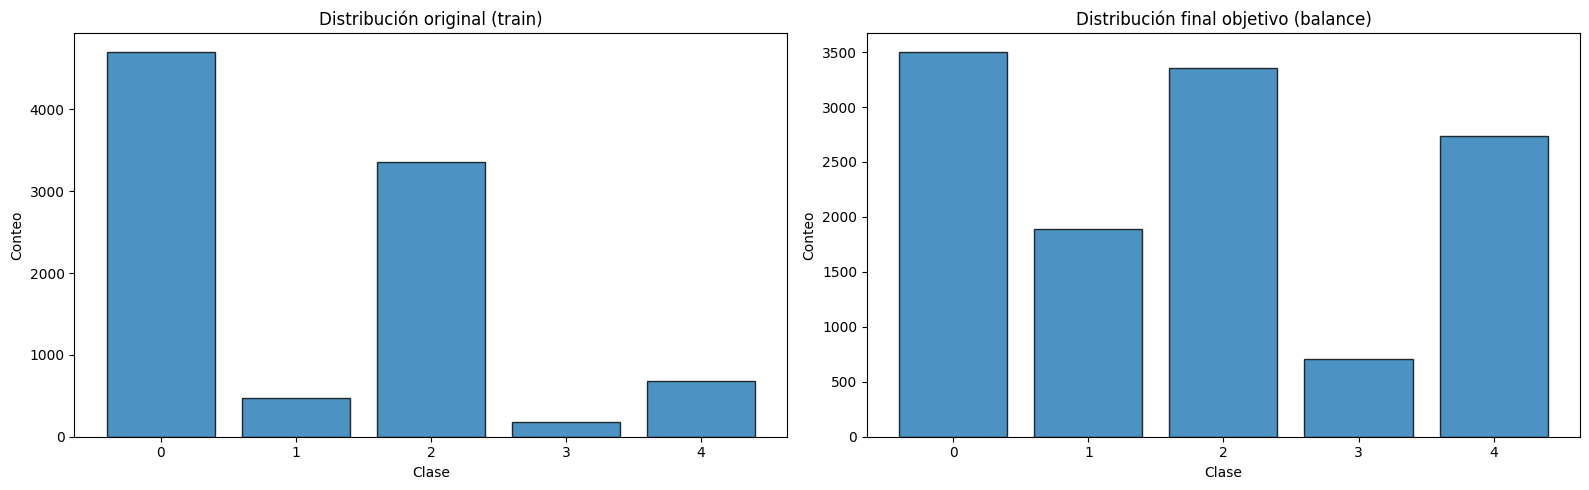

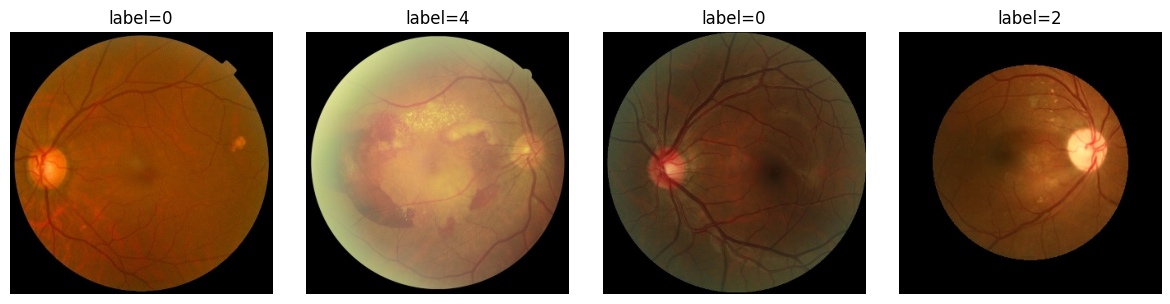

In [10]:
# Resumen consolidado: rutas, splits, distribuciones y visualización de muestras.
print("=== Resumen de pipeline ===")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Split train base: {len(base_dataset_train)}")
print(f"Split all base: {len(base_dataset_all)}")
print(f"images_batch shape: {tuple(images_batch.shape)}")
print(f"labels_batch shape: {tuple(labels_batch.shape)}")
print(f"Distribución original (train): {class_counts.to_dict()}")
print(f"Distribución final objetivo: {final_counts_series.to_dict()}")
print(f"Ratio original: {original_imbalance_ratio:.2f}:1")
print(f"Ratio final: {final_imbalance_ratio:.2f}:1")

# Graficar distribución original vs final objetivo.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes_sorted = sorted(class_counts.index.tolist())
x = np.arange(len(classes_sorted))
orig_values = [int(class_counts.loc[c]) for c in classes_sorted]
final_values = [int(final_counts_series.loc[c]) for c in classes_sorted]

axes[0].bar(x, orig_values, edgecolor="black", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes_sorted)
axes[0].set_title("Distribución original (train)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Conteo")

axes[1].bar(x, final_values, edgecolor="black", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted)
axes[1].set_title("Distribución final objetivo (balance)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()

# Mostrar muestras del batch de la baseline.
n_show = min(4, images_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    image_vis = images_batch[i].detach().cpu().clamp(0.0, 1.0)
    axes[i].imshow(np.transpose(image_vis.numpy(), (1, 2, 0)))
    axes[i].set_title(f"label={int(labels_batch[i])}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Justificación de la fusión de 5 clases a 3 clases

Esto es igual a la entrega 4. Después de aplicar aumento de datos en las cinco clases originales, vimos que algunas categorías siguen muy desbalanceadas y que las fronteras entre severidades adyacentes (1 vs 2, 3 vs 4) son especialmente ruidosas. Intentamos entrenar respetando las 5 clases, pero los resultados no fueron buenos, el modelo confundía sistemáticamente los pares adyacentes.

Por eso decidimos fusionar clases 1 + 2 en una sola (retinopatía leve-moderada) y clases 3 + 4 en otra (retinopatía severa-proliferativa), manteniendo la clase 0 (sin retinopatía). Esto reduce la ambigüedad clínica entre grados que incluso los oftalmólogos confunden con frecuencia, aumenta las muestras por clase resultante y mantiene la distinción clínicamente relevante. Sin DR, DR no severa y DR severa.

Los resultados se reportan en el espacio de 3 clases, así que no son directamente comparables con benchmarks de 5 clases. El merge reduce granularidad, pero mejora estabilidad y confiabilidad de las predicciones.

### Ajuste metodológico previo al feature engineering

Antes de extraer características hacemos algunos ajustes para que el entrenamiento sea más estable e interpretable. Reducimos de 5 a 3 clases agrupando etiquetas cercanas (`0`, `1+2`, `3+4`) para disminuir la ambigüedad entre grados adyacentes. También buscamos un balance controlado entre clases, la clase 0 se limita a `MAJORITY_CAP` muestras, las clases 1 y 2 se expanden con augmentación geométrica (hflip, vflip, rotación) y se verifica la distribución final con `final_train_counts` y `final_train_proportions`.

La augmentación es geométrica simple, razonable para imágenes de retina donde la orientación no define la patología. Se aplica CLAHE de forma consistente en train y val para evitar cambios de distribución entre conjuntos.

La distribución que se muestra en esta sección corresponde al dataset final que entra al modelo, no a una etapa intermedia.

## 5) Funciones auxiliares

Agregamos funciones auxiliares para los siguientes procesos de fine-tuning y entrenamiento. 

In [ ]:
# Funciones auxiliares para el feature engineering

# En las siguientes funciones, aplicamos las transformaciones:
# 1) Convertir RGB a escala de grises.
# 2) Calcular features globales: media/desviación por canal RGB + histograma en escala de grises.
# 3) Aplicar CLAHE en espacio BGR y devolver imagen PIL en RGB.
# 4) Preparar imagen para el backbone.
# 5) Aplicar augmentación geométrica si corresponde.
# 6) Preparar imagen para el backbone.

def _imagenet_stats_from_weights(weights_enum: object) -> tuple[list[float], list[float]]:
    weights = weights_enum.DEFAULT
    mean = list(weights.meta.get("mean", (0.485, 0.456, 0.406)))
    std = list(weights.meta.get("std", (0.229, 0.224, 0.225)))
    return mean, std


def _imagenet_stats_from_convnext_tiny() -> tuple[list[float], list[float]]:
    return _imagenet_stats_from_weights(ConvNeXt_Tiny_Weights)


def _to_gray(x: torch.Tensor) -> torch.Tensor:
    """Convertir RGB a escala de grises (tensor CHW en [0,1])."""
    r, g, b = x[0], x[1], x[2]
    return (0.2989 * r + 0.5870 * g + 0.1140 * b).clamp(0.0, 1.0)


def _global_features(x: torch.Tensor, hist_bins: int = 16) -> torch.Tensor:
    """Calcular features globales: media/desviación por canal RGB + histograma en escala de grises.

    Se concatenan como vector auxiliar al embedding del backbone.
    """
    ch_mean = x.mean(dim=(1, 2))
    ch_std = x.std(dim=(1, 2), unbiased=False)

    gray = _to_gray(x)
    hist = torch.histc(gray, bins=int(hist_bins), min=0.0, max=1.0)
    hist = hist / (hist.sum().clamp_min(1.0))

    return torch.cat([ch_mean, ch_std, hist], dim=0).float()


def _apply_geometry(
    image: torch.Tensor,
    aug_id: int,
    idx: int,
    seed: int,
) -> torch.Tensor:
    """Aplicar augmentación geométrica simple, reproducible por índice y semilla.

    aug_id: 0=original, 1=hflip, 2=vflip, 3=rotación aleatoria [10°-15°].
    """
    if int(aug_id) == 0:
        return image
    if int(aug_id) == 1:
        return TF.hflip(image)
    if int(aug_id) == 2:
        return TF.vflip(image)

    rng = np.random.default_rng(int(seed) + int(idx))
    mag = float(rng.uniform(10.0, 15.0))
    sign = -1.0 if rng.random() < 0.5 else 1.0
    angle = sign * mag

    return TF.rotate(
        image,
        angle=float(angle),
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )


LABEL_MAP_5_TO_3: dict[int, int] = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}


class MappedLabelDataset(Dataset):
    """Envolver un dataset base y remapear sus etiquetas preservando soporte de _rows."""

    def __init__(self, base_dataset: DDR2019Dataset, label_map: dict[int, int]) -> None:
        self.base_dataset = base_dataset
        self.label_map = dict(label_map)
        self._rows = self.base_dataset._rows.copy()
        self._rows["label"] = self._rows["label"].map(self.label_map).astype(int)

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        image, label = self.base_dataset[int(idx)]
        return image, int(self.label_map[int(label)])


class ClahePILTransform:
    """Aplicar CLAHE en espacio BGR y devolver imagen PIL en RGB."""

    def __call__(self, image: Image.Image) -> Image.Image:
        rgb = np.asarray(image.convert("RGB"), dtype=np.uint8)
        bgr = np.ascontiguousarray(rgb[..., ::-1])
        bgr_clahe = apply_clahe_bgr(bgr)
        rgb_clahe = np.ascontiguousarray(bgr_clahe[..., ::-1])
        return Image.fromarray(rgb_clahe)


class BaselineSingleFeatureDataset(Dataset):
    """Dataset baseline: imagen preprocesada para el backbone + features globales auxiliares.

    Cada muestra devuelve un diccionario con:
    - 'image': tensor normalizado listo para el backbone.
    - 'extra': vector de features globales (estadísticas de canal + histograma).
    - 'label': etiqueta (ya mapeada si corresponde).
    """

    def __init__(
        self,
        base_dataset: "DDR2019Dataset",
        samples: list[tuple[int, int]],
        seed: int,
        image_size: int = 224,
        hist_bins: int = 16,
        mean: list[float] | None = None,
        std: list[float] | None = None,
    ) -> None:
        self.base_dataset = base_dataset
        self.samples = list(samples)
        self.seed = int(seed)
        self.image_size = int(image_size)
        self.hist_bins = int(hist_bins)

        convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()
        self.mean = list(convnext_mean if mean is None else mean)
        self.std = list(convnext_std if std is None else std)

    def __len__(self) -> int:
        return len(self.samples)

    # Preparamos la imagen para el backbone.
    def _prep_for_backbone(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = TF.resize(
            x,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        x = x.float().clamp(0.0, 1.0)

        extra = _global_features(x, hist_bins=self.hist_bins)
        x_norm = TF.normalize(x, mean=self.mean, std=self.std)
        return x_norm, extra

    def __getitem__(self, item_idx: int) -> dict[str, torch.Tensor]:
        base_index, aug_id = self.samples[int(item_idx)]
        image, label = self.base_dataset[int(base_index)]
        image = image.float().clamp(0.0, 1.0)

        # Aplicamos la augmentación geométrica si corresponde.
        image_aug = _apply_geometry(
            image,
            aug_id=int(aug_id),
            idx=int(base_index),
            seed=self.seed,
        )

        # Preparamos la imagen para el backbone.
        image_in, extra = self._prep_for_backbone(image_aug)

        return {
            "image": image_in,
            "extra": extra,
            "label": torch.tensor(int(label), dtype=torch.long),
        }


def build_convnext_tiny_feature_extractor() -> nn.Module:
    """Construir ConvNeXt-Tiny preentrenado como extractor de features: salida (B, 768)."""
    model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    model.classifier[2] = nn.Identity()

    # Congelamos todos los parámetros del modelo.
    # Posteriormente, descongelamos los parámetros de la cabeza
    # para que se actualicen durante el fine-tuning.
    for p in model.parameters():
        p.requires_grad = False

    return model


def _forward_backbone_features(feature_model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    out = feature_model(image)
    if isinstance(out, torch.Tensor):
        return out
    if isinstance(out, (tuple, list)):
        out0 = out[0]
        if not isinstance(out0, torch.Tensor):
            raise TypeError("Backbone output tuple/list does not contain tensor features.")
        return out0
    if isinstance(out, dict):
        for key in ("features", "logits", "out"):
            if key in out and isinstance(out[key], torch.Tensor):
                return out[key]
    raise TypeError(f"Unsupported backbone output type: {type(out)}")


@torch.no_grad()
def extract_backbone_features(
    feature_model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    desc: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Extraer features concatenadas (embedding del backbone + features globales auxiliares).

    Recorre el DataLoader completo en modo evaluación, concatena todos los vectores
    y devuelve matrices numpy (X, y) listas para entrenar un modelo tabular.
    """
    feature_model = feature_model.to(device)
    feature_model.eval()

    feats: list[np.ndarray] = []
    labels: list[np.ndarray] = []

    for batch in tqdm(loader, desc=desc, total=len(loader)):
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].detach().cpu().numpy()

        f = _forward_backbone_features(feature_model, image)
        f = torch.cat([f, extra], dim=1)

        feats.append(f.detach().cpu().numpy())
        labels.append(y)

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)

    print("Dimensión de la matriz de features:", X.shape)
    return X, y


#### Funciones reutilizables para fine-tuning de ConvNeXt-Tiny con búsqueda HP

In [12]:

def sample_hparams_random(
    n_trials: int,
    seed: int,
    head_lr_low: float = 1e-4,
    head_lr_high: float = 2e-3,
    backbone_lr_low: float = 5e-6,
    backbone_lr_high: float = 2e-4,
    wd_low: float = 1e-5,
    wd_high: float = 5e-3,
    head_dropout_options: list[float] | None = None,
    unfreeze_blocks_options: list[int] | None = None,
) -> list[dict]:
    """Muestrear *n_trials* configuraciones para fine-tuning de un modelo preentrenado.

    Se utilizan tasas de aprendizaje diferenciadas para la cabeza (head) y el
    backbone, ya que la cabeza se entrena desde cero mientras que el backbone
    solo requiere ajustes finos sobre pesos preentrenados.
    """

    # Agregamos valores por defecto si no se proporcionan
    if head_dropout_options is None:
        head_dropout_options = [0.3, 0.4, 0.5]
    if unfreeze_blocks_options is None:
        unfreeze_blocks_options = [2, 3]

    # Inicializamos el generador de números aleatorios
    rng = np.random.default_rng(seed)
    trials = []

    # Generar configuraciones aleatorias para el fine-tuning
    # La lógica detrás consiste en:
    # - Los candidatos para el Learning Rate de la cabeza son más grandes que para el backbone.
    # - Los candidatos para el número de bloques a descongelar son más pequeños que para el backbone.
    # - Los candidatos para el dropout son más grandes que para el backbone.
    # - Los candidatos para el weight decay son más grandes que para el backbone.

    for _ in range(n_trials):
        head_lr = float(np.exp(rng.uniform(np.log(head_lr_low), np.log(head_lr_high))))
        backbone_lr = float(np.exp(rng.uniform(np.log(backbone_lr_low), np.log(backbone_lr_high))))
        wd = float(np.exp(rng.uniform(np.log(wd_low), np.log(wd_high))))
        dropout = float(rng.choice(head_dropout_options))
        unfreeze = int(rng.choice(unfreeze_blocks_options))

        # Concatenamos los parámetros en un diccionario y lo agregamos a la lista de trials
        trials.append({
            "head_lr": head_lr,
            "backbone_lr": backbone_lr,
            "weight_decay": wd,
            "head_dropout": dropout,
            "unfreeze_blocks": unfreeze,
        })
    return trials


def make_stratified_subset(
    samples: list[tuple[int, int]],
    labels: np.ndarray,
    fraction: float,
    seed: int,
) -> tuple[list[tuple[int, int]], np.ndarray]:
    """Subconjunto estratificado de *samples* usando StratifiedShuffleSplit."""

    # Inicializamos el generador de números aleatorios
    sss = StratifiedShuffleSplit(n_splits=1, train_size=fraction, random_state=seed)

    # Obtenemos los índices del subconjunto estratificado
    subset_idx, _ = next(sss.split(np.zeros(len(labels)), labels))

    # Obtenemos los samples y labels del subconjunto estratificado
    subset_samples = [samples[i] for i in subset_idx]
    subset_labels = labels[subset_idx]
    
    return subset_samples, subset_labels


def build_convnext_tiny_for_finetuning(
    num_classes: int = 3,
    head_dropout: float = 0.0,
    unfreeze_blocks: int = 0,
) -> nn.Module:
    """ConvNeXt-Tiny preentrenado con cabeza de clasificación entrenable.

    Parámetros para fine-tuning controlado de modelos preentrenados:
    - head_dropout: regularización en la cabeza para evitar sobreajuste.
    - unfreeze_blocks: cantidad de bloques superiores del backbone a descongelar.
      Si es 0, se descongelan TODOS los parámetros (fine-tuning completo).
    """

    model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

    if unfreeze_blocks > 0:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-unfreeze_blocks:].parameters():
            p.requires_grad = True

    in_features = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],       # LayerNorm
        model.classifier[1],       # Flatten
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def _run_one_ft_epoch(model, loader, optimizer, criterion, device, is_train: bool,
                      epoch_desc: str = "", scheduler=None):
    """Ejecutar una época de fine-tuning (train o eval)."""

    # Si es entrenamiento, ponemos el modelo en modo entrenamiento
    # Si es evaluación, ponemos el modelo en modo evaluación
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []
    ctx = torch.no_grad() if not is_train else torch.enable_grad()

    phase = "Train" if is_train else "Val"
    bar_desc = f"{epoch_desc} {phase}" if epoch_desc else phase

    # Iteramos sobre el loader
    with ctx:
        for batch in tqdm(loader, desc=bar_desc, leave=False):
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Si es entrenamiento, actualizamos el scheduler
    if is_train and scheduler is not None:
        scheduler.step()

    # Concatenamos todos los preds y labels
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Calculamos la pérdida promedio y el F1 macro
    avg_loss = total_loss / len(all_labels)
    macro_f1 = float(f1_score(all_labels, all_preds, average="macro", zero_division=0))

    return avg_loss, macro_f1


def kfold_finetune_eval(
    trial: dict,
    subset_samples: list[tuple[int, int]],
    subset_labels: np.ndarray,
    base_dataset,
    k: int,
    epochs: int,
    seed: int,
    device: torch.device,
    num_classes: int = 3,
    batch_size: int = 32,
    image_size: int = 224,
    hist_bins: int = 16,
    label_smoothing: float = 0.0,
    patience: int = 0,
    scheduler_eta_min: float = 1e-6,
) -> dict:
    """Evaluar un trial con K-Fold CV sobre el subconjunto estratificado.

    Implementa prácticas estándar para fine-tuning de modelos preentrenados:
    - LR diferenciado (head vs backbone).
    - Weighted CrossEntropyLoss + label smoothing.
    - CosineAnnealingLR.
    - Early stopping opcional por fold.
    """

    # Extraemos los parámetros del trial
    head_lr = trial["head_lr"]
    backbone_lr = trial["backbone_lr"]
    wd = trial["weight_decay"]
    head_dropout = trial["head_dropout"]
    unfreeze_blocks = trial["unfreeze_blocks"]
    convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()

    # Inicializamos el StratifiedKFold, el cual divide el dataset en k folds estratificados
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    fold_scores: list[float] = []
    t0 = time.perf_counter()

    # Iteramos sobre los folds
    folds_iter = list(enumerate(skf.split(np.zeros(len(subset_labels)), subset_labels)))
    for fold_idx, (train_idx, val_idx) in tqdm(folds_iter, desc=f"Folds (hlr={head_lr:.1e})", leave=False):
        # Obtenemos los samples y labels del fold
        fold_train_samples = [subset_samples[i] for i in train_idx]
        fold_val_samples = [subset_samples[i] for i in val_idx]
        fold_train_labels = subset_labels[train_idx]

        # Creamos los datasets para el fold
        fold_train_ds = BaselineSingleFeatureDataset(
            base_dataset=base_dataset,
            samples=fold_train_samples,
            seed=seed,
            image_size=image_size,
            hist_bins=hist_bins,
            mean=convnext_mean,
            std=convnext_std,
        )

        # Creamos el dataset para el fold de validación
        fold_val_ds = BaselineSingleFeatureDataset(
            base_dataset=base_dataset,
            samples=fold_val_samples,
            seed=seed,
            image_size=image_size,
            hist_bins=hist_bins,
            mean=convnext_mean,
            std=convnext_std,
        )
        fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        # Inicializamos el generador de números aleatorios
        torch.manual_seed(seed + fold_idx)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed + fold_idx)

        # Creamos el modelo para el fold
        model = build_convnext_tiny_for_finetuning(
            num_classes, head_dropout=head_dropout, unfreeze_blocks=unfreeze_blocks,
        ).to(device)

        # Obtenemos los parámetros de la cabeza y el backbone
        head_params = list(model.classifier.parameters())
        head_param_ids = {id(p) for p in head_params}
        backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_param_ids]

        # Creamos el optimizador para el fold
        optimizer = torch.optim.AdamW([
            {"params": head_params, "lr": head_lr},
            {"params": backbone_params, "lr": backbone_lr},
        ], weight_decay=wd)

        # Creamos la clase de pesos para el loss
        class_weights = compute_class_weights(fold_train_labels, num_classes).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)

        # Creamos el scheduler para el fold
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=scheduler_eta_min)

        best_val_f1 = -1.0
        epochs_no_improve = 0

        # Iteramos sobre las épocas, este es el bucle principal de fine-tuning
        for epoch in tqdm(range(epochs), desc=f"Fold {fold_idx+1} épocas", leave=False):
            _run_one_ft_epoch(
                model, fold_train_loader, optimizer, criterion, device,
                is_train=True, epoch_desc=f"F{fold_idx+1} E{epoch+1}",
                scheduler=scheduler,
            )
            if patience > 0:
                _, ef1 = _run_one_ft_epoch(
                    model, fold_val_loader, None, criterion, device,
                    is_train=False, epoch_desc=f"F{fold_idx+1} ES",
                )
                if ef1 > best_val_f1:
                    best_val_f1 = ef1
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        break

        _, val_f1 = _run_one_ft_epoch(
            model, fold_val_loader, None, criterion, device,
            is_train=False, epoch_desc=f"F{fold_idx+1}",
        )
        fold_scores.append(val_f1)

        # Liberamos memoria al final de cada fold
        del model, optimizer, scheduler
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Calculamos el tiempo transcurrido y devolvemos el diccionario de resultados
    elapsed = time.perf_counter() - t0

    # Devolvemos el diccionario de resultados
    return {
        "head_lr": head_lr,
        "backbone_lr": backbone_lr,
        "weight_decay": wd,
        "head_dropout": head_dropout,
        "unfreeze_blocks": unfreeze_blocks,
        "fold_scores": fold_scores,
        "mean_f1": float(np.mean(fold_scores)),
        "std_f1": float(np.std(fold_scores)),
        "elapsed_s": elapsed,
    }


def finetune_full(
    head_lr: float,
    backbone_lr: float,
    wd: float,
    train_samples: list[tuple[int, int]],
    train_labels: np.ndarray,
    base_dataset,
    epochs: int,
    seed: int,
    device: torch.device,
    num_classes: int = 3,
    batch_size: int = 32,
    image_size: int = 224,
    hist_bins: int = 16,
    head_dropout: float = 0.0,
    unfreeze_blocks: int = 0,
    label_smoothing: float = 0.0,
    scheduler_eta_min: float = 1e-6,
) -> nn.Module:
    """Fine-tunear ConvNeXt-Tiny en el conjunto COMPLETO de entrenamiento.

    Usa LR diferenciado, weighted CE, CosineAnnealingLR y label smoothing
    según las mejores prácticas para fine-tuning de modelos preentrenados.
    """

    # Obtenemos las estadísticas de imagenet para el backbone
    convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()

    # Creamos el dataset para el entrenamiento
    train_ds = BaselineSingleFeatureDataset(
        base_dataset=base_dataset,
        samples=train_samples,
        seed=seed,
        image_size=image_size,
        hist_bins=hist_bins,
        mean=convnext_mean,
        std=convnext_std,
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)

    # Inicializamos el generador de números aleatorios
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Creamos el modelo para el entrenamiento
    model = build_convnext_tiny_for_finetuning(
        num_classes, head_dropout=head_dropout, unfreeze_blocks=unfreeze_blocks,
    ).to(device)

    # Obtenemos los parámetros de la cabeza y el backbone
    head_params = list(model.classifier.parameters())
    head_param_ids = {id(p) for p in head_params}
    backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_param_ids]

    # Creamos el optimizador para el entrenamiento
    optimizer = torch.optim.AdamW([
        {"params": head_params, "lr": head_lr},
        {"params": backbone_params, "lr": backbone_lr},
    ], weight_decay=wd)

    # Creamos la clase de pesos para el loss
    class_weights = compute_class_weights(train_labels, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)

    # Creamos el scheduler para el entrenamiento
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=scheduler_eta_min)

    # Iteramos sobre las épocas, este es el bucle principal de fine-tuning en modo de entrenamiento
    for epoch in tqdm(range(epochs), desc="Fine-tuning final", leave=True):
        loss, f1 = _run_one_ft_epoch(
            model, train_loader, optimizer, criterion, device,
            is_train=True, epoch_desc=f"E{epoch+1}/{epochs}",
            scheduler=scheduler,
        )
        current_head_lr = optimizer.param_groups[0]["lr"]
        current_bb_lr = optimizer.param_groups[1]["lr"] if backbone_params else 0.0
        print(f"  Época {epoch + 1}/{epochs} — loss: {loss:.4f}, macro-F1: {f1:.4f}, "
              f"head_lr: {current_head_lr:.2e}, bb_lr: {current_bb_lr:.2e}")

    return model


def compute_class_weights(labels: np.ndarray, num_classes: int) -> torch.FloatTensor:
    """Pesos inversamente proporcionales a la frecuencia de cada clase.

    Estándar para datasets desbalanceados en clasificación de imágenes médicas:
    weight[c] = total / (num_classes * count[c]).
    """

    # Calculamos la frecuencia de cada clase
    counts = np.bincount(labels.astype(int), minlength=num_classes).astype(float)
    counts = np.maximum(counts, 1.0)

    # Calculamos los pesos inversamente proporcionales a la frecuencia de cada clase
    weights = float(len(labels)) / (num_classes * counts)
    return torch.FloatTensor(weights)


def convert_to_feature_extractor(model: nn.Module) -> nn.Module:
    """Convertir modelo fine-tuneado en extractor de features."""

    # Reemplazamos la cabeza por una Identity
    model.classifier[2] = nn.Identity()
    model.classifier[3] = nn.Identity()

    # Congelamos todos los parámetros del modelo
    # Posteriormente, se descongelarán los parámetros de un número determinado de bloques
    # dependiendo de la configuración de hiperparámetros.
    for p in model.parameters():
        p.requires_grad = False
    model.eval()

    return model

Pasos a seguir para el preprocesamiento de los datos y el entrenamiento del modelo

In [13]:
# 1) Cargar dataset con CLAHE consistente en train y val.
# CLAHE mejora el contraste local, lo cual ayuda a resaltar estructuras retinales.
# Se aplica el mismo preprocesamiento a ambos splits para evitar cambios de distribución.
DATA_DIR_BASELINE = DATA_DIR

# Creamos el transformador para el preprocesamiento de los datos
clahe_to_tensor = transforms.Compose([
    ClahePILTransform(),
    transforms.ToTensor(),
])

# Creamos el dataset para el entrenamiento
baseline_train_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="train",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=clahe_to_tensor,
    random_state=SEED,
)

# Creamos el dataset para la validación
baseline_val_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="val",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=clahe_to_tensor,
    random_state=SEED,
)

# Creamos el dataset para el entrenamiento
baseline_train_ds = MappedLabelDataset(baseline_train_ds_raw, LABEL_MAP_5_TO_3)

# Creamos el dataset para la validación
baseline_val_ds = MappedLabelDataset(baseline_val_ds_raw, LABEL_MAP_5_TO_3)

print("Dataset baseline - decisiones de datos")
print(f"  DATA_DIR_BASELINE: {DATA_DIR_BASELINE}")
print(f"  train samples: {len(baseline_train_ds)}")
print(f"  val samples  : {len(baseline_val_ds)}")
print(f"  mapeo de etiquetas usado (5-3): {LABEL_MAP_5_TO_3}")
print(f"  etiquetas presentes en train tras mapeo: {sorted(baseline_train_ds._rows['label'].unique().tolist())}")
print("  consistencia de preprocesamiento: CLAHE se aplica tanto a train como a val")

Dataset baseline - decisiones de datos
  DATA_DIR_BASELINE: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
  train samples: 9389
  val samples  : 3133
  mapeo de etiquetas usado (5-3): {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
  etiquetas presentes en train tras mapeo: [0, 1, 2]
  consistencia de preprocesamiento: CLAHE se aplica tanto a train como a val


In [14]:
# 2) Estrategia de muestreo tras el merge 5->3 clases.

# Política por clase en entrenamiento:
# - Clase 0: se mantiene tal cual (sin augmentación).
# - Clase 1: se mantiene, pero se barajan los ejemplos para variabilidad.
# - Clase 2: se aplica augmentación ×4 (original + 3 variantes geométricas).
# Validación: solo merge de etiquetas, sin augmentación.

train_rows_baseline = baseline_train_ds._rows.reset_index(drop=True).copy()
class_counts_baseline = train_rows_baseline["label"].value_counts().sort_index()

# Definimos los modos de augmentación para la clase 2
CLASS2_AUGMENTATION_MODES = [0, 1, 2, 3]

# Inicializamos el generador de números aleatorios
rng = np.random.default_rng(SEED)

# Creamos la lista de samples para el entrenamiento
train_samples: list[tuple[int, int]] = []

for class_id in sorted(int(x) for x in class_counts_baseline.index.tolist()):
    class_indices = train_rows_baseline[train_rows_baseline["label"] == class_id].index.to_numpy()

    # Barajar clase 1 explícitamente para romper cualquier orden implícito.
    # Barajar clase 1 para romper cualquier orden implícito del dataset.
    if class_id == 1:
        class_indices = rng.permutation(class_indices)

    if class_id == 2:
        # ×4 solo para la clase severa fusionada (nueva clase 2).
        for aug_id in CLASS2_AUGMENTATION_MODES:
            train_samples.extend((int(idx), int(aug_id)) for idx in class_indices.tolist())
    else:
        # Clases 0 y 1: solo la imagen original.
        train_samples.extend((int(idx), 0) for idx in class_indices.tolist())

# Distribución final que efectivamente usa el modelo para entrenar.
train_counts_after_aug = (
    pd.Series([int(train_rows_baseline.loc[int(idx), "label"]) for idx, _ in train_samples])
    .value_counts()
    .sort_index()
)

# Calculamos la proporción final que efectivamente usa el modelo para entrenar
train_proportions_after_aug = (train_counts_after_aug / train_counts_after_aug.sum()).sort_index()

print("Resumen de augmentación del set de entrenamiento (estrategia aplicada):")
print(f"  merged class_counts (raw train split): {class_counts_baseline.to_dict()}")
print(f"  clase 0: solo original")
print(f"  clase 1: solo original + orden barajado")
print(f"  clase 2: ×4 con modos {CLASS2_AUGMENTATION_MODES}")
print(f"  final_train_counts used by model: {train_counts_after_aug.to_dict()}")
print(
    "  final_train_proportions used by model (%): "
    + str({int(k): round(float(v) * 100.0, 2) for k, v in train_proportions_after_aug.items()})
)

# Validación mantiene distribución natural (etiquetas fusionadas, sin augmentación).
val_samples = [(int(i), 0) for i in range(len(baseline_val_ds))]

# Verificaciones rápidas de integridad.
print("Verificaciones de integridad:")
print(f"  train_samples: {len(train_samples)}")
print(f"  val_samples  : {len(val_samples)}")
print(f"  labels in train rows: {sorted(class_counts_baseline.index.astype(int).tolist())}")

check_idx = int(train_rows_baseline[train_rows_baseline["label"] == 2].index[0])
img_base, _ = baseline_train_ds[check_idx]
img_rot = _apply_geometry(img_base, aug_id=3, idx=check_idx, seed=SEED)
print(f"  augmentation changed sample (class 2, rotation): {bool(not torch.allclose(img_base, img_rot))}")

Resumen de augmentación del set de entrenamiento (estrategia aplicada):
  merged class_counts (raw train split): {0: 4699, 1: 3829, 2: 861}
  clase 0: solo original
  clase 1: solo original + orden barajado
  clase 2: ×4 con modos [0, 1, 2, 3]
  final_train_counts used by model: {0: 4699, 1: 3829, 2: 3444}
  final_train_proportions used by model (%): {0: 39.25, 1: 31.98, 2: 28.77}
Verificaciones de integridad:
  train_samples: 11972
  val_samples  : 3133
  labels in train rows: [0, 1, 2]
  augmentation changed sample (class 2, rotation): True


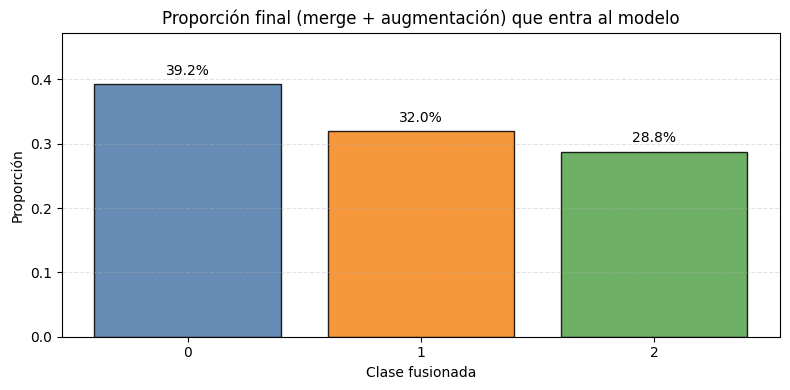

In [15]:
# Gráfica de la distribución proporcional final (después de merge + augmentación).
fig, ax = plt.subplots(figsize=(8, 4))

# Preparamos la gráfica para la distribución proporcional final (después de merge + augmentación).
bars = ax.bar(
    train_proportions_after_aug.index.astype(str),
    train_proportions_after_aug.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    edgecolor="black",
    alpha=0.85,
)

# Agregamos los valores de la proporción final a la gráfica
for bar, prop in zip(bars, train_proportions_after_aug.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{prop * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Configuramos y mostramos la gráfica
ax.set_title("Proporción final (merge + augmentación) que entra al modelo")
ax.set_xlabel("Clase fusionada")
ax.set_ylabel("Proporción")
ax.set_ylim(0, min(1.0, float(train_proportions_after_aug.max()) + 0.08))
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [16]:
# Verificación: confirmar que train_samples y val_samples existen.
# La estrategia de muestreo/augmentación se define en la celda anterior;
# esta celda solo valida que están disponibles para las siguientes etapas.

if "train_samples" not in globals() or "val_samples" not in globals():
    raise RuntimeError(
        "No se encontraron train_samples/val_samples. Ejecuta primero la celda de estrategia de muestreo."
    )

print("Estrategia activa verificada: train_samples y val_samples ya están definidos.")
print(f"  train_samples: {len(train_samples)}")
print(f"  val_samples  : {len(val_samples)}")

Estrategia activa verificada: train_samples y val_samples ya están definidos.
  train_samples: 11972
  val_samples  : 3133


## 6) Búsqueda de hiperparámetros para fine-tuning de ConvNeXt-Tiny

En las entregas anteriores, ConvNeXt-Tiny se usó como extractor de features **congelado** (sin fine-tuning). Ahora agregamos una etapa de fine-tuning del backbone para adaptar las representaciones al dominio de retinopatía diabética.

**Estrategia:**
1. **Subconjunto estratificado:** para reducir el costo de cómputo, la búsqueda de hiperparámetros se realiza sobre un subconjunto del conjunto de entrenamiento (fracción configurable, ~30 %), preservando la proporción de clases.
2. **Random search:** se muestrean pares `(lr, weight_decay)` con distribución log-uniforme.
3. **K-Fold cross-validation:** cada par se evalúa con validación cruzada estratificada (k=3) usando pocas épocas. La métrica de selección es **macro-F1**.
4. **Re-entrenamiento final:** el mejor par se usa para fine-tunear ConvNeXt-Tiny en el conjunto de entrenamiento **completo** con más épocas.
5. **Extracción de features:** el modelo fine-tuneado se convierte en extractor de features (se reemplaza la cabeza por `Identity`), y se conecta al pipeline de XGBoost existente.

**Guardrails:** la búsqueda y el K-Fold solo tocan datos de entrenamiento; el set de validación se mantiene intacto hasta la evaluación final con XGBoost.

In [17]:
# --- Configuración de la búsqueda de hiperparámetros para fine-tuning ---
# Los rangos están calibrados para fine-tuning de modelos preentrenados
# (ConvNeXt-Tiny) en tareas de clasificación de imágenes médicas con
# desbalance de clases.

# Se utiliza un subconjunto de 40% de los datos para la búsqueda de hiperparámetros.
# Anteriormente se usó 30%, pero creemos que con más datos se puede encontrar mejores hiperparámetros.
SUBSET_FRACTION = 0.40

N_TRIALS = 20

# Se utiliza 3-Fold CV para la búsqueda de hiperparámetros. 
K_FOLDS = 3

# Se utiliza 5 épocas para la búsqueda de hiperparámetros.
FT_EPOCHS_SEARCH = 5

# Se utiliza 12 épocas para el re-entrenamiento final.
FT_EPOCHS_FINAL = 12

EARLY_STOPPING_PATIENCE = 3
NUM_CLASSES = 3

LABEL_SMOOTHING = 0.05

# Se ajustan los hiperparámetros para tratar de encontrar mejores combinaciones.
# En la iteración pasada, el mejor trial tiene backbone_lr = 1.83e-04, 
# muy cerca del límite superior elegido de 2e-04. 
# Esto sugiere que el modelo podría beneficiarse de un learning rate de backbone más alto
HEAD_LR_LOW, HEAD_LR_HIGH = 5e-5, 2e-3

# Un caso similar se observó para weight_decay, que se ajustó a un rango más amplio
# con respecto a la iteración anterior. Antes el rango era 5e-6, 2e-4
BACKBONE_LR_LOW, BACKBONE_LR_HIGH = 1e-5, 1e-3

# Estos valores se eligieron en un rango estandar para weight decay.
# No parecen acercarse a los límites en otros experimentos, por lo que se mantienen.
WD_LOW, WD_HIGH = 1e-5, 1e-2

# Ampliamos el rango de dropout para permitir más regularización por dropout.
HEAD_DROPOUT_OPTIONS = [0.3, 0.4, 0.5, 0.6]

# Se inicia de 3 porque en la iteración anterior el mejor trial usó 3,
# queremos observar si el modelo puede mejorar con más unfreezing.
UNFREEZE_BLOCKS_OPTIONS = [3, 4, 5]

FT_BATCH_SIZE = 32
IMAGE_SIZE = 320
HIST_BINS = 16
SCHEDULER_ETA_MIN = 1e-6

print("Configuración de búsqueda de HP para fine-tuning:")
print(f"  SUBSET_FRACTION        = {SUBSET_FRACTION}")
print(f"  N_TRIALS               = {N_TRIALS}")
print(f"  K_FOLDS                = {K_FOLDS}")
print(f"  FT_EPOCHS_SEARCH       = {FT_EPOCHS_SEARCH}")
print(f"  FT_EPOCHS_FINAL        = {FT_EPOCHS_FINAL}")
print(f"  EARLY_STOPPING_PATIENCE= {EARLY_STOPPING_PATIENCE}")
print(f"  LABEL_SMOOTHING        = {LABEL_SMOOTHING}")
print(f"  IMAGE_SIZE             = {IMAGE_SIZE}")
print(f"  FT_BATCH_SIZE          = {FT_BATCH_SIZE}")
print(f"  head_lr: [{HEAD_LR_LOW:.0e}, {HEAD_LR_HIGH:.0e}] (log-uniforme)")
print(f"  backbone_lr: [{BACKBONE_LR_LOW:.0e}, {BACKBONE_LR_HIGH:.0e}] (log-uniforme)")
print(f"  wd: [{WD_LOW:.0e}, {WD_HIGH:.0e}] (log-uniforme)")
print(f"  head_dropout: {HEAD_DROPOUT_OPTIONS}")
print(f"  unfreeze_blocks: {UNFREEZE_BLOCKS_OPTIONS}")

Configuración de búsqueda de HP para fine-tuning:
  SUBSET_FRACTION        = 0.4
  N_TRIALS               = 20
  K_FOLDS                = 3
  FT_EPOCHS_SEARCH       = 5
  FT_EPOCHS_FINAL        = 12
  EARLY_STOPPING_PATIENCE= 3
  LABEL_SMOOTHING        = 0.05
  IMAGE_SIZE             = 320
  FT_BATCH_SIZE          = 32
  head_lr: [5e-05, 2e-03] (log-uniforme)
  backbone_lr: [1e-05, 1e-03] (log-uniforme)
  wd: [1e-05, 1e-02] (log-uniforme)
  head_dropout: [0.3, 0.4, 0.5, 0.6]
  unfreeze_blocks: [3, 4, 5]


In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# 1) Obtener etiquetas de cada muestra en train_samples.
ft_labels = np.array(
    [int(train_rows_baseline.loc[int(idx), "label"]) for idx, _ in train_samples],
    dtype=np.int64,
)

# 2) Crear subconjunto estratificado para la búsqueda rápida.
subset_samples, subset_labels = make_stratified_subset(
    train_samples, ft_labels, fraction=SUBSET_FRACTION, seed=SEED,
)

# 3) Muestrear configuraciones de HP.
hp_trials = sample_hparams_random(
    N_TRIALS, seed=SEED,
    head_lr_low=HEAD_LR_LOW, head_lr_high=HEAD_LR_HIGH,
    backbone_lr_low=BACKBONE_LR_LOW, backbone_lr_high=BACKBONE_LR_HIGH,
    wd_low=WD_LOW, wd_high=WD_HIGH,
    head_dropout_options=HEAD_DROPOUT_OPTIONS,
    unfreeze_blocks_options=UNFREEZE_BLOCKS_OPTIONS,
)

# Agregamos un resumen de los hiperparámetros muestreados.
print(f"\n{N_TRIALS} configuraciones muestreadas:")
for i, t in enumerate(hp_trials):
    print(f"  Trial {i+1:>2d}: head_lr={t['head_lr']:.4e}, bb_lr={t['backbone_lr']:.4e}, "
          f"wd={t['weight_decay']:.4e}, dropout={t['head_dropout']:.1f}, "
          f"unfreeze={t['unfreeze_blocks']}")


Dispositivo: cuda

20 configuraciones muestreadas:
  Trial  1: head_lr=8.6875e-04, bb_lr=7.5467e-05, wd=3.7652e-03, dropout=0.3, unfreeze=5
  Trial  2: head_lr=7.0770e-05, bb_lr=8.9381e-04, wd=1.9205e-03, dropout=0.5, unfreeze=5
  Trial  3: head_lr=8.0208e-05, bb_lr=7.9574e-05, wd=1.2954e-04, dropout=0.3, unfreeze=5
  Trial  4: head_lr=5.3763e-04, bb_lr=4.4210e-04, wd=2.1392e-04, dropout=0.4, unfreeze=3
  Trial  5: head_lr=3.8677e-04, bb_lr=1.3416e-05, wd=3.0401e-03, dropout=0.4, unfreeze=4
  Trial  6: head_lr=8.1935e-04, bb_lr=5.1174e-05, wd=8.1676e-03, dropout=0.4, unfreeze=5
  Trial  7: head_lr=8.8305e-04, bb_lr=2.4506e-05, wd=2.5128e-04, dropout=0.4, unfreeze=3
  Trial  8: head_lr=8.8339e-05, bb_lr=2.3233e-04, wd=1.7151e-03, dropout=0.4, unfreeze=5
  Trial  9: head_lr=1.6633e-04, bb_lr=5.5071e-05, wd=2.5625e-04, dropout=0.6, unfreeze=3
  Trial 10: head_lr=8.0744e-05, bb_lr=8.9415e-05, wd=4.7943e-05, dropout=0.5, unfreeze=5
  Trial 11: head_lr=2.5079e-04, bb_lr=4.6276e-04, wd=1.2612

In [ ]:
# 4) Evaluar cada trial con K-Fold CV sobre el subconjunto.
ft_search_results: list[dict] = []
print(
    f"Iniciando búsqueda: {N_TRIALS} trials, {K_FOLDS}-Fold CV, "
    f"{FT_EPOCHS_SEARCH} épocas por fold"
)

# Iteramos sobre las diferentes configuraciones de hiperparámetros.
for i, trial in enumerate(tqdm(hp_trials, desc="HP trials"), start=1):
    result = kfold_finetune_eval(
        trial=trial,
        subset_samples=subset_samples,
        subset_labels=subset_labels,
        base_dataset=baseline_train_ds,
        k=K_FOLDS,
        epochs=FT_EPOCHS_SEARCH,
        seed=SEED,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        batch_size=FT_BATCH_SIZE,
        image_size=IMAGE_SIZE,
        hist_bins=HIST_BINS,
        label_smoothing=LABEL_SMOOTHING,
        patience=EARLY_STOPPING_PATIENCE,
        scheduler_eta_min=SCHEDULER_ETA_MIN,
    )
    ft_search_results.append(result)
    tqdm.write(
        f"Trial {i:>2d}/{N_TRIALS}: macro-F1={result['mean_f1']:.4f} ± "
        f"{result['std_f1']:.4f} ({result['elapsed_s']:.1f}s)"
    )

print("Búsqueda de hiperparámetros completada.")

NOTA: Eliminamos los outputs de esta celda de forma intencional, porque eran demasiado y no aportan valor.

In [ ]:
# Tabla resumen de resultados de la búsqueda de hiperparámetros.
ft_results_df = pd.DataFrame(ft_search_results).drop(columns=["fold_scores"])
ft_results_df = ft_results_df.sort_values(
    ["mean_f1", "std_f1", "elapsed_s"],
    ascending=[False, True, True],
).reset_index(drop=True)
ft_results_df.index = ft_results_df.index + 1
ft_results_df.index.name = "rank"


print("Leaderboard - Búsqueda de hiperparámetros para fine-tuning ConvNeXt-Tiny")

# Mostramos los 5 mejores trials por macro-F1 medio (K-Fold CV sobre subconjunto)
display(ft_results_df.head(5).style.format({
    "head_lr": "{:.4e}",
    "backbone_lr": "{:.4e}",
    "weight_decay": "{:.4e}",
    "head_dropout": "{:.1f}",
    "unfreeze_blocks": "{:d}",
    "mean_f1": "{:.4f}",
    "std_f1": "{:.4f}",
    "elapsed_s": "{:.1f}",
}).set_caption("Top 5 trials por macro-F1 medio (K-Fold CV sobre subconjunto)"))

# Obtenemos el mejor trial
best_row = ft_results_df.iloc[0]

# Obtenemos los parámetros de la cabeza y el backbone
best_head_lr = best_row["head_lr"]
best_backbone_lr = best_row["backbone_lr"]
best_wd = best_row["weight_decay"]
best_head_dropout = best_row["head_dropout"]
best_unfreeze_blocks = int(best_row["unfreeze_blocks"])

print(f"\nMejores hiperparámetros seleccionados:")
print(f"  head_lr        = {best_head_lr:.6e}")
print(f"  backbone_lr    = {best_backbone_lr:.6e}")
print(f"  weight_decay   = {best_wd:.6e}")
print(f"  head_dropout   = {best_head_dropout:.1f}")
print(f"  unfreeze_blocks= {best_unfreeze_blocks}")
print(f"  mean macro-F1  = {best_row['mean_f1']:.4f} ± {best_row['std_f1']:.4f}")


Leaderboard - Búsqueda de hiperparámetros para fine-tuning ConvNeXt-Tiny


,head_lr,backbone_lr,weight_decay,head_dropout,unfreeze_blocks,mean_f1,std_f1,elapsed_s
rank,,,,,,,,
1,8.8339e-05,2.3233e-04,1.7151e-03,0.4,5,0.8938,0.0016,648.9
2,9.1132e-04,2.1365e-04,1.3047e-03,0.4,5,0.8915,0.0051,655.5
3,5.8856e-04,8.7537e-05,4.9626e-04,0.3,5,0.8880,0.0057,654.0
4,1.4768e-04,2.1078e-04,4.6892e-04,0.5,5,0.8879,0.0023,650.8
5,5.3763e-04,4.4210e-04,2.1392e-04,0.4,3,0.8867,0.0078,568.2



Mejores hiperparámetros seleccionados:
  head_lr        = 8.833870e-05
  backbone_lr    = 2.323260e-04
  weight_decay   = 1.715088e-03
  head_dropout   = 0.4
  unfreeze_blocks= 5
  mean macro-F1  = 0.8938 ± 0.0016


In [19]:
best_head_lr        = 8.833870e-05
best_backbone_lr    = 2.323260e-04
best_wd   = 1.715088e-03
best_head_dropout   = 0.4
best_unfreeze_blocks= 5


In [20]:
# Re-entrenamiento final con los mejores hiperparámetros sobre el conjunto COMPLETO.
print(f"Fine-tuning final de ConvNeXt-Tiny ({FT_EPOCHS_FINAL} épocas)")
print(f"  head_lr={best_head_lr:.4e}, bb_lr={best_backbone_lr:.4e}, wd={best_wd:.4e}")
print(f"  dropout={best_head_dropout:.1f}, unfreeze_blocks={best_unfreeze_blocks}")
print(f"  Dataset completo: {len(train_samples)} muestras")

ft_model = finetune_full(
    head_lr=best_head_lr,
    backbone_lr=best_backbone_lr,
    wd=best_wd,
    train_samples=train_samples,
    train_labels=ft_labels,
    base_dataset=baseline_train_ds,
    epochs=FT_EPOCHS_FINAL,
    seed=SEED,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    batch_size=FT_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    head_dropout=best_head_dropout,
    unfreeze_blocks=best_unfreeze_blocks,
    label_smoothing=LABEL_SMOOTHING,
    scheduler_eta_min=SCHEDULER_ETA_MIN,
)

feature_model_finetuned = convert_to_feature_extractor(ft_model)
print("\nModelo fine-tuneado convertido a extractor de features (cabeza = Identity, parámetros congelados).")

Fine-tuning final de ConvNeXt-Tiny (12 épocas)
  head_lr=8.8339e-05, bb_lr=2.3233e-04, wd=1.7151e-03
  dropout=0.4, unfreeze_blocks=5
  Dataset completo: 11972 muestras


Fine-tuning final:   0%|          | 0/12 [00:00<?, ?it/s]

E1/12 Train:   0%|          | 0/375 [00:00<?, ?it/s]

  Época 1/12 — loss: 0.5356, macro-F1: 0.8111, head_lr: 8.69e-05, bb_lr: 2.28e-04


E2/12 Train:   0%|          | 0/375 [00:00<?, ?it/s]

...

  Época 10/12 — loss: 0.1786, macro-F1: 0.9978, head_lr: 6.85e-06, bb_lr: 1.65e-05


E11/12 Train:   0%|          | 0/375 [00:00<?, ?it/s]

  Época 11/12 — loss: 0.1784, macro-F1: 0.9984, head_lr: 2.49e-06, bb_lr: 4.94e-06


E12/12 Train:   0%|          | 0/375 [00:00<?, ?it/s]

  Época 12/12 — loss: 0.1778, macro-F1: 0.9980, head_lr: 1.00e-06, bb_lr: 1.00e-06

Modelo fine-tuneado convertido a extractor de features (cabeza = Identity, parámetros congelados).


## 7) Feature extraction con ConvNeXt-Tiny fine-tuned + XGBoost

En esta sección se utilizan los embeddings extraídos del modelo ConvNeXt-Tiny fine-tuneado (sección 7) como entrada al pipeline de XGBoost. El modelo fine-tuneado adapta las representaciones del backbone al dominio de retinopatía diabética, lo que puede mejorar la calidad de los features respecto al backbone congelado.

Se realiza un refinamiento de hiperparámetros de XGBoost con `RandomizedSearchCV` (`n_iter=20`, `cv=3`) sobre los nuevos embeddings.

In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 320
BATCH_SIZE = 32
HIST_BINS = 16

convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()

train_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_train_ds,
    samples=train_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    mean=convnext_mean,
    std=convnext_std,
)
val_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_val_ds,
    samples=val_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    mean=convnext_mean,
    std=convnext_std,
)

train_loader = DataLoader(train_fe_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader = DataLoader(val_fe_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Dispositivo: {DEVICE}")
print(f"Train: {len(train_fe_ds)} muestras | Val: {len(val_fe_ds)} muestras")

Dispositivo: cuda
Train: 11972 muestras | Val: 3133 muestras


In [22]:
# En este bloque se extraen los features del modelo ConvNeXt-Tiny fine-tuneado.
# Posteriormente, se realiza un refinamiento de hiperparámetros de XGBoost con 
# RandomizedSearchCV(n_iter=20, cv=3) sobre los nuevos embeddings.
# Finalmente, se entrena el modelo XGBoost con los mejores hiperparámetros encontrados.

feature_model = feature_model_finetuned
print("ConvNeXt-Tiny fine-tuned feature extractor cargado (parámetros congelados).")

X_train, y_train = extract_backbone_features(feature_model, train_loader, DEVICE, desc="Extrayendo features (train)")
X_val, y_val = extract_backbone_features(feature_model, val_loader, DEVICE, desc="Extrayendo features (val)")

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")

ConvNeXt-Tiny fine-tuned feature extractor cargado (parámetros congelados).


Extrayendo features (train):   0%|          | 0/375 [00:00<?, ?it/s]

Dimensión de la matriz de features: (11972, 790)


Extrayendo features (val):   0%|          | 0/98 [00:00<?, ?it/s]

Dimensión de la matriz de features: (3133, 790)
X_train: (11972, 790), y_train: (11972,)
X_val:   (3133, 790),   y_val:   (3133,)


La busqueda de los nuevos hiperparámetros se realiza con base en los hiperparámetros encontrados en la entrega anterior.

In [23]:
PREV_BEST_F1 = 0.834218


# Para la busqueda de los nuevos hiperparámetros se utiliza el espacio de búsqueda definido en la entrega anterior.
# Es decir, se toman los valores del mejor trial de la entrega anterior como centro del espacio de búsqueda.
param_distributions = {
    "n_estimators": randint(150, 350),
    "max_depth": [4, 5, 6, 7],
    "learning_rate": uniform(0.10, 0.12),          # ~[0.10, 0.22] centrado en 0.17
    "subsample": uniform(0.70, 0.20),              # ~[0.70, 0.90] centrado en 0.79
    "colsample_bytree": uniform(0.80, 0.15),       # ~[0.80, 0.95] centrado en 0.90
    "gamma": uniform(0.05, 0.40),                  # ~[0.05, 0.45] centrado en 0.24
    "min_child_weight": randint(4, 9),             # {4,5,6,7,8} centrado en 6
    "reg_alpha": uniform(0.05, 0.25),              # ~[0.05, 0.30] centrado en 0.16
    "reg_lambda": uniform(1.2, 1.4),               # ~[1.2, 2.6] centrado en 1.83
}

print("Espacio de búsqueda definido (rangos estrechos alrededor del mejor previo):")
for k, v in param_distributions.items():
    if isinstance(v, list):
        print(f"  {k}: {v}")
    elif hasattr(v, "interval"):
        lo, hi = v.interval(1.0)
        print(f"  {k}: [{lo}, {hi}]")
    else:
        print(f"  {k}: {v}")

Espacio de búsqueda definido (rangos estrechos alrededor del mejor previo):
  n_estimators: [149.0, 349.0]
  max_depth: [4, 5, 6, 7]
  learning_rate: [0.1, 0.22]
  subsample: [0.7, 0.8999999999999999]
  colsample_bytree: [0.8, 0.9500000000000001]
  gamma: [0.05, 0.45]
  min_child_weight: [3.0, 8.0]
  reg_alpha: [0.05, 0.3]
  reg_lambda: [1.2, 2.5999999999999996]


In [24]:
# Se agregan ajuste para el uso de GPU con XGBoost
xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
xgb_gpu_jobs = 2 if xgb_device == "cuda" else min(8, os.cpu_count() or 1)
print(f"XGBoost device: {xgb_device}")

base_xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    device=xgb_device,
    max_bin=256,
    random_state=SEED,
    n_jobs=xgb_gpu_jobs,
)

scoring = make_scorer(f1_score, average="macro")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=1,
    refit=True,
)

print("Iniciando RandomizedSearchCV: ConvNeXt-Tiny + XGBoost (refinamiento)")
print(f"  n_iter=20, cv=3, scoring=macro-F1")
t0 = time.perf_counter()
search.fit(X_train, y_train)
elapsed_sec = time.perf_counter() - t0
print(f"Búsqueda completada en {elapsed_sec:.1f}s.")

XGBoost device: cuda
Iniciando RandomizedSearchCV: ConvNeXt-Tiny + XGBoost (refinamiento)
  n_iter=20, cv=3, scoring=macro-F1
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/home/anaya/Development/Robomous/sam-ai/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [22:26:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Búsqueda completada en 41.9s.


In [25]:
# A continuación se muestran los resultados de la búsqueda de hiperparámetros
print(f"Mejor CV macro-F1 (nuevo): {search.best_score_:.4f}")
print(f"Mejor CV macro-F1 (previo): {PREV_BEST_F1:.4f}")
delta = search.best_score_ - PREV_BEST_F1
print(f"Diferencia: {delta:+.4f}")

print("\nMejores hiperparámetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

xgb_best = search.best_estimator_

Mejor CV macro-F1 (nuevo): 0.9998
Mejor CV macro-F1 (previo): 0.8342
Diferencia: +0.1656

Mejores hiperparámetros encontrados:
  colsample_bytree: 0.8561810178271044
  gamma: 0.43028572256396647
  learning_rate: 0.1878392730173686
  max_depth: 4
  min_child_weight: 8
  n_estimators: 252
  reg_alpha: 0.1614581882133978
  reg_lambda: 1.339964882145204
  subsample: 0.7918497783931734


## 8) Resultados

En este espacio se muestran los resultados del entrenamiento y evaluación del modelo final después de haber aplicado el preprocesamiento y el entrenamiento con XGBoost con los mejores hiperparámetros encontrados.

In [26]:
y_pred = xgb_best.predict(X_val)
y_train_pred = xgb_best.predict(X_train)

val_f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
train_f1_macro = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

metrics = compute_eval_metrics(y_val, y_pred)
print("Validation macro-F1 (ConvNeXt-Tiny + XGBoost)")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

print()
print("Modelo final reportado - classification report")
print(classification_report(y_val, y_pred, digits=4, zero_division=0))

print("Señal de generalización (train limpio vs validación)")
print(f"  Entrenamiento macro-F1: {train_f1_macro:.4f}")
print(f"  Validación    macro-F1: {val_f1_macro:.4f}")
print(f"  Brecha (train - val):   {(train_f1_macro - val_f1_macro):.4f}")

Validation macro-F1 (ConvNeXt-Tiny + XGBoost)
  val_accuracy: 0.8688
  val_precision_macro: 0.8617
  val_recall_macro: 0.8344
  val_f1_macro: 0.8468

Modelo final reportado - classification report
              precision    recall  f1-score   support

           0     0.8825    0.9298    0.9055      1567
           1     0.8548    0.8200    0.8371      1278
           2     0.8477    0.7535    0.7978       288

    accuracy                         0.8688      3133
   macro avg     0.8617    0.8344    0.8468      3133
weighted avg     0.8680    0.8688    0.8677      3133

Señal de generalización (train limpio vs validación)
  Entrenamiento macro-F1: 0.9999
  Validación    macro-F1: 0.8468
  Brecha (train - val):   0.1531


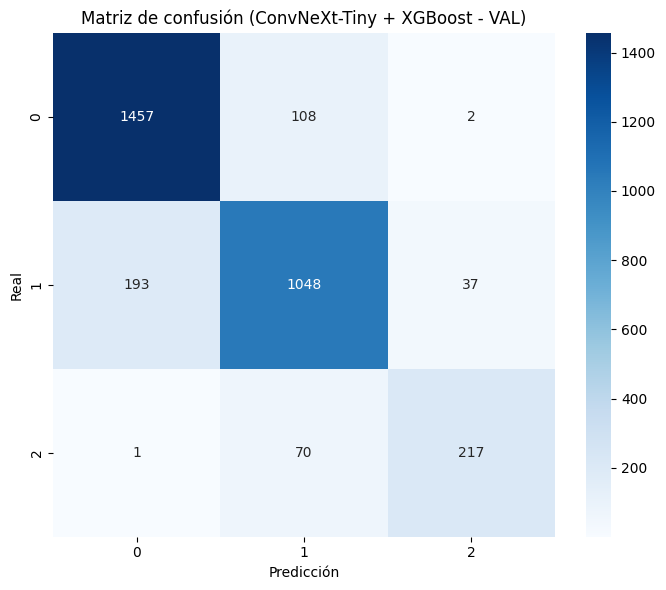

In [27]:
labels_sorted = sorted(int(x) for x in np.unique(y_val))
cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
)
plt.title("Matriz de confusión (ConvNeXt-Tiny + XGBoost - VAL)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Importancia de características

En este modelo, las características corresponden a las 768 dimensiones del embedding de ConvNeXt-Tiny
más 22 features globales auxiliares (estadísticas de canal RGB + histograma en escala de grises).
La importancia se obtiene directamente del modelo XGBoost (ganancia promedio).

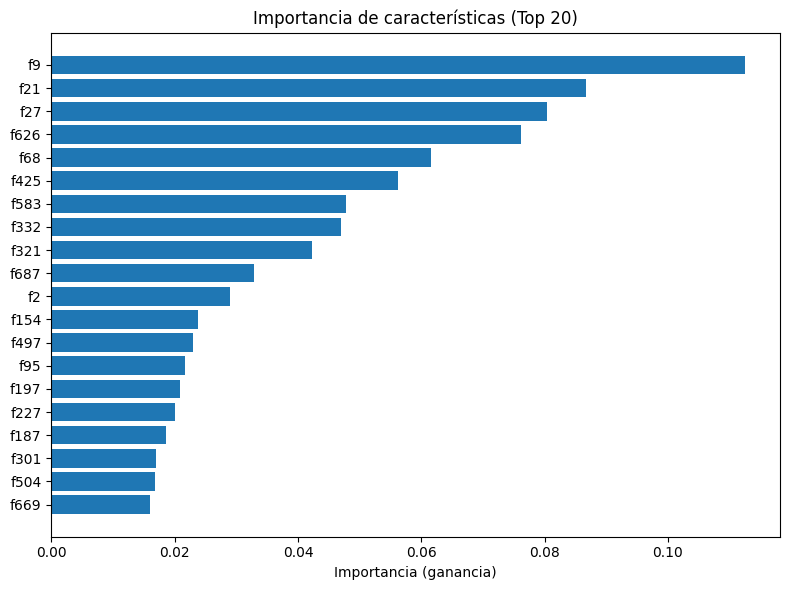

Top características por importancia (XGBoost):


,feature,importance
0,f9,0.112539
1,f21,0.086780
2,f27,0.080454
3,f626,0.076181
4,f68,0.061603
5,f425,0.056195
6,f583,0.047801
7,f332,0.046947
8,f321,0.042314
9,f687,0.032903


In [28]:
importances = xgb_best.feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": [f"f{i}" for i in range(len(importances))],
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 20
top_df = importance_df.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"][::-1], top_df["importance"][::-1])
plt.xlabel("Importancia (ganancia)")
plt.title(f"Importancia de características (Top {top_k})")
plt.tight_layout()
plt.show()

print("Top características por importancia (XGBoost):")
display(top_df)

## 9) Re-evaluación de modelos individuales sobre embeddings fine-tuneados

Dado que el backbone `ConvNeXt-Tiny` fue fine-tuneado en la sección anterior, el espacio de embeddings cambió respecto a la fase previa. Por lo tanto, es necesario re-evaluar múltiples clasificadores individuales sobre las nuevas representaciones fine-tuneadas antes de utilizarlos como componentes de los ensembles.

Se evalúan los siguientes modelos individuales:
- **XGBoost**: ya afinado con `RandomizedSearchCV` en la sección 7.
- **LightGBM**: otro algoritmo de boosting basado en árboles, con alta eficiencia y buen rendimiento en datos tabulares.
- **LinearSVC**: clasificador lineal de máquinas de soporte vectorial, envuelto en `CalibratedClassifierCV` para obtener probabilidades mediante calibración Platt (sigmoid). Se necesita la calibración porque `LinearSVC` no soporta `predict_proba` de forma nativa.
- **ExtraTrees**: ensemble de árboles extremadamente aleatorios (bagging). Usa `class_weight="balanced"` para mitigar el desbalance de clases.
- **Logistic Regression**: clasificador lineal probabilístico, útil como baseline estable.

Los 3 mejores modelos individuales por Macro-F1 serán seleccionados como base learners para los ensembles heterogéneos.

### Justificación metodológica

En esta fase nos enfocamos en el aprendizaje por ensembles para aprovechar las fortalezas complementarias de diferentes clasificadores y reducir sus debilidades individuales. Dado que realizamos fine-tuning del backbone `ConvNeXt-Tiny`, el espacio de características (embeddings) cambió respecto a la fase anterior. Por ello, re-evaluamos múltiples clasificadores individuales sobre los embeddings fine-tuneados para identificar los base learners más fuertes bajo la nueva representación.

Incluimos modelos como `ExtraTrees` para representar un ensemble homogéneo basado en bagging que es robusto al ruido y puede reducir la varianza, y `Logistic Regression` como meta-learner en stacking/blending porque proporciona una forma simple, estable y bien calibrada de aprender combinaciones óptimas de las predicciones de los modelos base. `Logistic Regression` no fue priorizada como candidato individual en la fase anterior; aquí se introduce principalmente como meta-modelo para aumentar la diversidad del ensemble y para probar empíricamente si un combinador lineal puede mejorar la generalización sobre datos no vistos.

In [29]:
TOP_K = 3

individual_configs = [
    ("XGBoost", xgb_best, True),
    ("LightGBM", LGBMClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1,
        class_weight="balanced",
    ), False),
    ("LinearSVC (Calibrado)", CalibratedClassifierCV(
        LinearSVC(max_iter=5000, random_state=SEED, class_weight="balanced"),
        method="sigmoid", cv=3,
    ), False),
    ("ExtraTrees", ExtraTreesClassifier(
        n_estimators=500, random_state=SEED, n_jobs=-1,
        class_weight="balanced",
    ), False),
    ("LogisticRegression", LogisticRegression(
        max_iter=1000, solver="lbfgs", C=1.0, random_state=SEED,
    ), False),
]

individual_results = []
individual_models_fitted = {}
individual_per_class_f1 = {}

for name, model, already_trained in tqdm(individual_configs, desc="Evaluando modelos individuales"):
    if already_trained:
        train_time_s = 0.0
    else:
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        train_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_proba = model.predict_proba(X_val)
    inference_time_s = time.perf_counter() - t0

    y_pred = np.argmax(y_proba, axis=1)
    macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_val, y_pred)
    bal_acc = balanced_accuracy_score(y_val, y_pred)
    per_class = f1_score(y_val, y_pred, average=None, zero_division=0)

    individual_per_class_f1[name] = per_class
    individual_models_fitted[name] = model

    individual_results.append({
        "model_name": name,
        "model_type": "Individual",
        "ensemble_type": "N/A",
        "strategy": "N/A",
        "macro_f1": macro_f1,
        "accuracy": acc,
        "balanced_acc": bal_acc,
        "train_time_s": train_time_s,
        "inference_time_s": inference_time_s,
    })

    print(f"\n--- {name} ---")
    print(f"  macro_f1       = {macro_f1:.4f}")
    print(f"  accuracy       = {acc:.4f}")
    print(f"  balanced_acc   = {bal_acc:.4f}")
    print(f"  train_time_s   = {train_time_s:.2f}")
    print(f"  inference_time = {inference_time_s:.4f}")

individual_results_df = (
    pd.DataFrame(individual_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
display(individual_results_df)

best_base_names = individual_results_df.head(TOP_K)["model_name"].tolist()
best_base_models = {name: individual_models_fitted[name] for name in best_base_names}

print(f"\nTop-{TOP_K} modelos individuales seleccionados como base learners:")
for rank, name in enumerate(best_base_names, 1):
    row = individual_results_df[individual_results_df["model_name"] == name].iloc[0]
    print(f"  {rank}. {name} — macro_f1 = {row['macro_f1']:.4f}")

Evaluando modelos individuales:   0%|          | 0/5 [00:00<?, ?it/s]


--- XGBoost ---
  macro_f1       = 0.8468
  accuracy       = 0.8688
  balanced_acc   = 0.8344
  train_time_s   = 0.00
  inference_time = 0.0279


/home/anaya/Development/Robomous/sam-ai/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- LightGBM ---
  macro_f1       = 0.8454
  accuracy       = 0.8659
  balanced_acc   = 0.8339
  train_time_s   = 4.24
  inference_time = 0.0113

--- LinearSVC (Calibrado) ---
  macro_f1       = 0.8479
  accuracy       = 0.8701
  balanced_acc   = 0.8353
  train_time_s   = 1.45
  inference_time = 0.0318

--- ExtraTrees ---
  macro_f1       = 0.8445
  accuracy       = 0.8675
  balanced_acc   = 0.8323
  train_time_s   = 0.79
  inference_time = 0.2138

--- LogisticRegression ---
  macro_f1       = 0.8467
  accuracy       = 0.8688
  balanced_acc   = 0.8356
  train_time_s   = 0.11
  inference_time = 0.0052


,model_name,model_type,ensemble_type,strategy,macro_f1,accuracy,balanced_acc,train_time_s,inference_time_s
0,LinearSVC (Calibrado),Individual,N/A,N/A,0.847924,0.870093,0.835303,1.448139,0.031784
1,XGBoost,Individual,N/A,N/A,0.846795,0.868816,0.834435,0.000000,0.027933
2,LogisticRegression,Individual,N/A,N/A,0.846748,0.868816,0.835620,0.111180,0.005160
3,LightGBM,Individual,N/A,N/A,0.845376,0.865943,0.833929,4.237954,0.011342
4,ExtraTrees,Individual,N/A,N/A,0.844533,0.867539,0.832272,0.788434,0.213819



Top-3 modelos individuales seleccionados como base learners:
  1. LinearSVC (Calibrado) — macro_f1 = 0.8479
  2. XGBoost — macro_f1 = 0.8468
  3. LogisticRegression — macro_f1 = 0.8467


### Interpretación de los resultados individuales

La tabla anterior muestra el rendimiento de cinco clasificadores individuales entrenados sobre los embeddings del backbone `ConvNeXt-Tiny` fine-tuneado. Todos los modelos alcanzan un Macro-F1 competitivo, lo que confirma que las representaciones adaptadas al dominio de retinopatía diabética son de alta calidad.

Los tres mejores modelos por Macro-F1 son seleccionados automáticamente como base learners para los ensembles heterogéneos. Aunque algunos de estos modelos coincidan con los evaluados en Avance 4, aquí operan sobre un espacio de embeddings distinto, lo que justifica su re-evaluación y hace de Avance 5 una etapa diferenciada enfocada en ensembling y generalización.

## 10) Ensembles: Homogéneos vs Heterogéneos

En esta sección se implementan y evalúan cuatro modelos ensemble sobre los embeddings extraídos del backbone ConvNeXt-Tiny fine-tuneado. Los top-3 modelos individuales identificados en la sección anterior son utilizados como base learners en los ensembles heterogéneos.

Se cubren las dos categorías de ensembles:

- **Homogéneo — Boosting**: `XGBoost` ya afinado con `RandomizedSearchCV`. Representa un ensemble homogéneo donde múltiples árboles se entrenan de forma secuencial, corrigiendo errores residuales.
- **Homogéneo — Bagging**: `ExtraTreesClassifier`. Entrena múltiples árboles en paralelo sobre submuestras aleatorias, reduciendo la varianza.
- **Heterogéneo — Stacking (OOF)**: Combina los top-3 modelos individuales como base learners con un meta-learner (`Logistic Regression`), utilizando predicciones *out-of-fold* para evitar data leakage.
- **Heterogéneo — Blending (Holdout)**: Mismos *base learners* que el stacking, pero utiliza un conjunto holdout interno (15%) para generar las meta-features.

Todos los ensembles operan directamente sobre `X_train` / `X_val` (embeddings de dimensión 790), sin re-extraer features del backbone.

#### Se definen las funciones auxiliares para el entrenamiento y evaluación de ensembles.

In [30]:
NUM_CLASSES = 3
ensemble_results = []
per_class_f1_records = dict(individual_per_class_f1)


def evaluate_ensemble(y_true, y_proba, label=""):
    """Evalúa un ensemble a partir de probabilidades predichas."""
    y_pred = np.argmax(y_proba, axis=1)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"--- {label} ---")
    print(f"  macro_f1       = {macro_f1:.4f}")
    print(f"  accuracy       = {acc:.4f}")
    print(f"  balanced_acc   = {bal_acc:.4f}")
    print()
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1_records[label] = per_class

    return {"macro_f1": macro_f1, "accuracy": acc, "balanced_acc": bal_acc}, y_pred


def train_and_predict_proba(model, X_tr, y_tr, X_te):
    """Entrena un modelo y devuelve probabilidades + tiempos."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    proba = model.predict_proba(X_te)
    inference_time_s = time.perf_counter() - t0

    return proba, train_time_s, inference_time_s


def plot_ensemble_confusion_matrix(y_true, y_pred, title):
    """Genera un heatmap de la matriz de confusión."""
    labels_sorted = sorted(int(x) for x in np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


### 10.1 Homogéneo - Boosting (XGBoost)

El primer ensemble homogéneo es el modelo `XGBoost` ya afinado con `RandomizedSearchCV` en la sección 7 (`xgb_best`). XGBoost es un algoritmo de gradient boosting que entrena árboles de decisión de forma secuencial, donde cada nuevo árbol corrige los errores residuales del anterior.

Se reutiliza directamente el modelo ya entrenado; aquí solo se mide el tiempo de inferencia y se registran las métricas de validación para la tabla comparativa.

--- XGBoost (Boosting) ---
  macro_f1       = 0.8468
  accuracy       = 0.8688
  balanced_acc   = 0.8344

              precision    recall  f1-score   support

           0     0.8825    0.9298    0.9055      1567
           1     0.8548    0.8200    0.8371      1278
           2     0.8477    0.7535    0.7978       288

    accuracy                         0.8688      3133
   macro avg     0.8617    0.8344    0.8468      3133
weighted avg     0.8680    0.8688    0.8677      3133



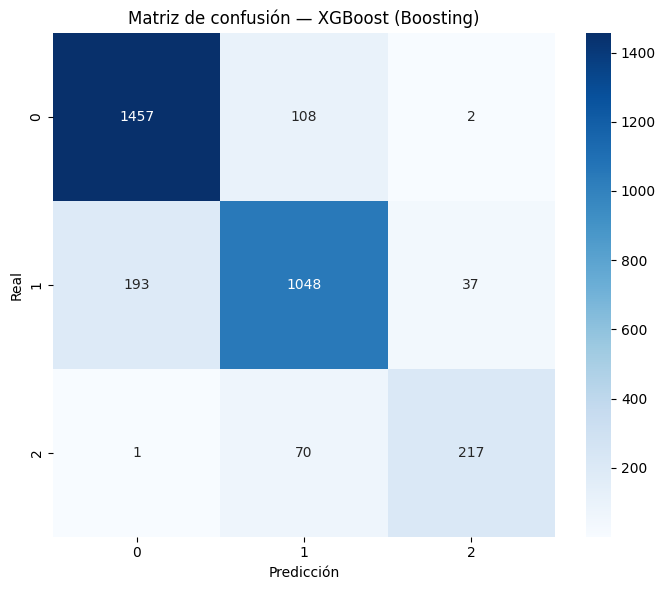

In [31]:
# XGBoost ya fue entrenado previamente; solo se mide inferencia.
t0 = time.perf_counter()
xgb_val_proba = xgb_best.predict_proba(X_val)
xgb_inference_time = time.perf_counter() - t0

xgb_metrics, xgb_val_pred = evaluate_ensemble(y_val, xgb_val_proba, label="XGBoost (Boosting)")

ensemble_results.append({
    "model_name": "XGBoost (Boosting)",
    "model_type": "Ensemble",
    "ensemble_type": "Homogéneo",
    "strategy": "Boosting",
    **xgb_metrics,
    "train_time_s": 0.0,
    "inference_time_s": xgb_inference_time,
})

plot_ensemble_confusion_matrix(y_val, xgb_val_pred,
                               "Matriz de confusión — XGBoost (Boosting)")

### 10.2 Homogéneo - Bagging (ExtraTrees)

El segundo ensemble homogéneo utiliza `ExtraTreesClassifier` (Extremely Randomized Trees) con 500 estimadores. A diferencia de Random Forest, ExtraTrees selecciona los puntos de corte de los árboles de forma completamente aleatoria, lo que reduce la varianza y suele ser más rápido de entrenar.

Funciona bajo el paradigma de bagging: entrena múltiples árboles en paralelo sobre submuestras bootstrap del conjunto de entrenamiento y promedia sus predicciones. Se utiliza `class_weight="balanced"` para compensar el desbalance de clases.

--- ExtraTrees (Bagging) ---
  macro_f1       = 0.8445
  accuracy       = 0.8675
  balanced_acc   = 0.8323

              precision    recall  f1-score   support

           0     0.8885    0.9209    0.9044      1567
           1     0.8453    0.8294    0.8373      1278
           2     0.8431    0.7465    0.7919       288

    accuracy                         0.8675      3133
   macro avg     0.8590    0.8323    0.8445      3133
weighted avg     0.8667    0.8675    0.8667      3133



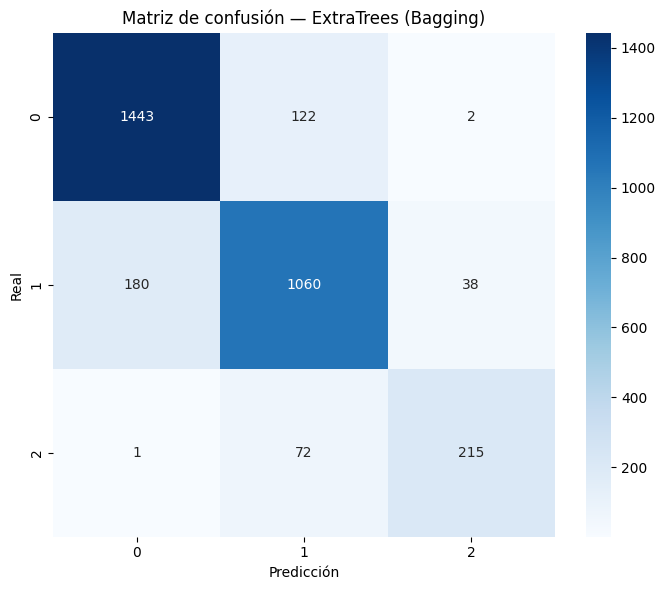

In [32]:
et_model = ExtraTreesClassifier(
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced",
)

et_val_proba, et_train_time, et_inference_time = train_and_predict_proba(
    et_model, X_train, y_train, X_val
)

et_metrics, et_val_pred = evaluate_ensemble(
    y_val, et_val_proba, label="ExtraTrees (Bagging)"
)

ensemble_results.append({
    "model_name": "ExtraTrees (Bagging)",
    "model_type": "Ensemble",
    "ensemble_type": "Homogéneo",
    "strategy": "Bagging",
    **et_metrics,
    "train_time_s": et_train_time,
    "inference_time_s": et_inference_time,
})

plot_ensemble_confusion_matrix(y_val, et_val_pred,
                               "Matriz de confusión — ExtraTrees (Bagging)")

### 10.3 Heterogéneo - Stacking (OOF)

El tercer ensemble es un stacking heterogéneo con predicciones out-of-fold (OOF). Combina los top-3 modelos individuales como base learners, y entrena un meta-learner (`Logistic Regression`) sobre las probabilidades que cada modelo base produce.

Procedimiento sin data leakage:
1. Se usa `StratifiedKFold(5)` para dividir el train set en 5 folds.
2. Para cada fold, se entrenan los base learners en el fold de entrenamiento y se predicen probabilidades en el fold OOF.
3. Las predicciones OOF se concatenan para formar las meta-features del train set completo.
4. Para el val set, se promedian las probabilidades de los 5 modelos entrenados por fold.
5. El meta-learner se entrena sobre las meta-features OOF y predice sobre las meta-features del val set.

Nota: Si `LinearSVC` aparece entre los top-3, ya se encuentra envuelto en `CalibratedClassifierCV`, por lo que `predict_proba` funciona correctamente.

Base learners para Stacking (top-3): ['LinearSVC (Calibrado)', 'XGBoost', 'LogisticRegression']


Stacking folds:   0%|          | 0/5 [00:00<?, ?it/s]

--- Stacking (OOF) ---
  macro_f1       = 0.8457
  accuracy       = 0.8679
  balanced_acc   = 0.8332

              precision    recall  f1-score   support

           0     0.8856    0.9241    0.9044      1567
           1     0.8488    0.8255    0.8370      1278
           2     0.8471    0.7500    0.7956       288

    accuracy                         0.8679      3133
   macro avg     0.8605    0.8332    0.8457      3133
weighted avg     0.8670    0.8679    0.8669      3133



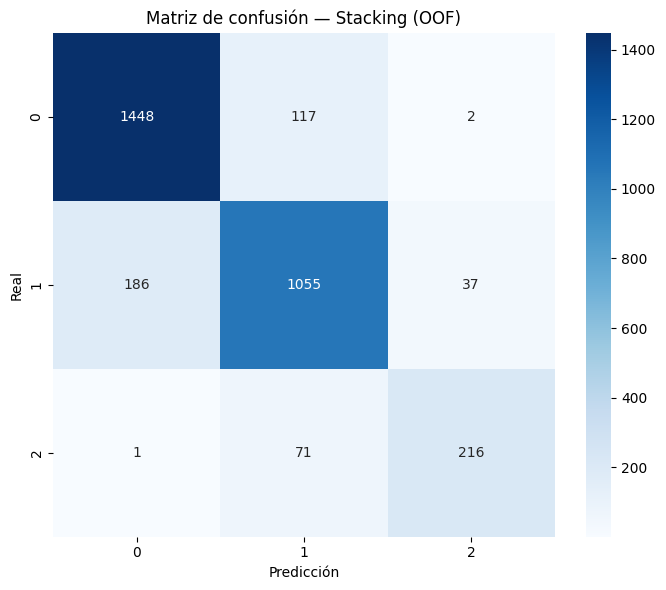

In [33]:
N_FOLDS_STACK = 5

print(f"Base learners para Stacking (top-{TOP_K}): {best_base_names}")

base_learner_configs = [
    (name, sklearn_clone(model)) for name, model in best_base_models.items()
]

n_base = len(base_learner_configs)
n_train = X_train.shape[0]
n_val = X_val.shape[0]

oof_train_meta = np.zeros((n_train, n_base * NUM_CLASSES))
val_meta_accum = np.zeros((n_val, n_base * NUM_CLASSES))

skf = StratifiedKFold(n_splits=N_FOLDS_STACK, shuffle=True, random_state=SEED)

t0_stack = time.perf_counter()

for fold_idx, (train_idx, oof_idx) in enumerate(
    tqdm(skf.split(X_train, y_train), total=N_FOLDS_STACK, desc="Stacking folds")
):
    X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
    X_fold_oof = X_train[oof_idx]

    for j, (name, base_template) in enumerate(base_learner_configs):
        model = sklearn_clone(base_template)
        model.fit(X_fold_train, y_fold_train)

        col_start = j * NUM_CLASSES
        col_end = col_start + NUM_CLASSES

        oof_train_meta[oof_idx, col_start:col_end] = model.predict_proba(X_fold_oof)
        val_meta_accum[:, col_start:col_end] += model.predict_proba(X_val)

val_meta_stacking = val_meta_accum / N_FOLDS_STACK

stack_meta_learner = LogisticRegression(
    max_iter=1000, solver="lbfgs",
    C=1.0, random_state=SEED,
)
stack_meta_learner.fit(oof_train_meta, y_train)

stack_train_time = time.perf_counter() - t0_stack

t0_inf = time.perf_counter()
stack_val_proba = stack_meta_learner.predict_proba(val_meta_stacking)
stack_inference_time = time.perf_counter() - t0_inf

stack_metrics, stack_val_pred = evaluate_ensemble(
    y_val, stack_val_proba, label="Stacking (OOF)"
)

ensemble_results.append({
    "model_name": "Stacking (OOF)",
    "model_type": "Ensemble",
    "ensemble_type": "Heterogéneo",
    "strategy": "Stacking",
    **stack_metrics,
    "train_time_s": stack_train_time,
    "inference_time_s": stack_inference_time,
})

plot_ensemble_confusion_matrix(y_val, stack_val_pred,
                               "Matriz de confusión — Stacking (OOF)")

### 10.4 Heterogéneo - Blending (Holdout)

El cuarto ensemble es un blending heterogéneo con un conjunto holdout interno. Utiliza los mismos top-3 modelos individuales que el Stacking como base learners. A diferencia del stacking OOF, el blending:

1. Divide `X_train` en dos partes: base-train (85%) y blend (15%), con muestreo estratificado.
2. Entrena los modelos base solo sobre base-train.
3. Genera meta-features prediciendo probabilidades sobre el conjunto blend.
4. Entrena un meta-learner (`Logistic Regression`) sobre las meta-features del blend.
5. Para evaluar en validación, los modelos base predicen sobre `X_val` y el meta-learner combina esas predicciones.

Este enfoque es más simple que el stacking OOF pero sacrifica datos de entrenamiento para construir las meta-features. Su principal ventaja es la evaluación directa sobre un holdout dedicado al meta-learner, sin el overhead computacional de los k folds.

Base learners para Blending (top-3): ['LinearSVC (Calibrado)', 'XGBoost', 'LogisticRegression']
Base-train: 10176 muestras | Blend: 1796 muestras


Blending: entrenando base learners:   0%|          | 0/3 [00:00<?, ?it/s]

--- Blending (Holdout) ---
  macro_f1       = 0.8475
  accuracy       = 0.8695
  balanced_acc   = 0.8358

              precision    recall  f1-score   support

           0     0.8831    0.9304    0.9062      1567
           1     0.8562    0.8200    0.8377      1278
           2     0.8450    0.7569    0.7985       288

    accuracy                         0.8695      3133
   macro avg     0.8614    0.8358    0.8475      3133
weighted avg     0.8686    0.8695    0.8683      3133



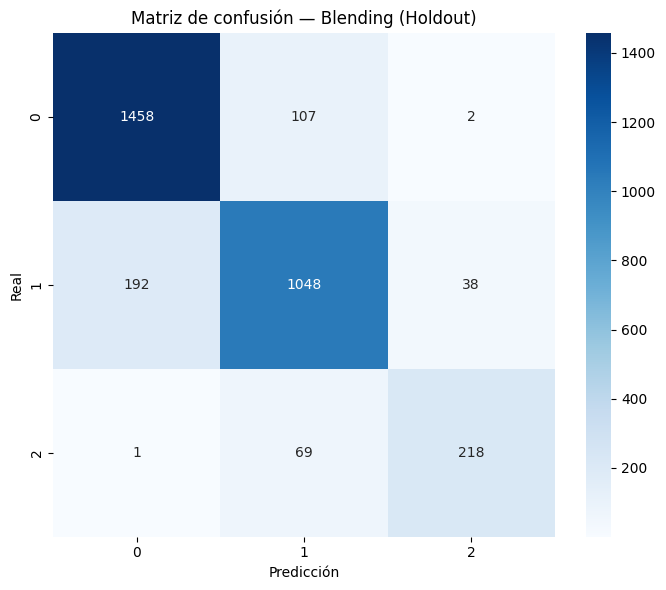

In [34]:
BLEND_TEST_SIZE = 0.15

print(f"Base learners para Blending (top-{TOP_K}): {best_base_names}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=BLEND_TEST_SIZE, random_state=SEED)
base_train_idx, blend_idx = next(sss.split(X_train, y_train))

X_base_train, y_base_train = X_train[base_train_idx], y_train[base_train_idx]
X_blend, y_blend = X_train[blend_idx], y_train[blend_idx]

print(f"Base-train: {X_base_train.shape[0]} muestras | Blend: {X_blend.shape[0]} muestras")

blend_base_configs = [
    (name, sklearn_clone(model)) for name, model in best_base_models.items()
]

blend_meta_train = np.zeros((X_blend.shape[0], len(blend_base_configs) * NUM_CLASSES))
blend_meta_val = np.zeros((n_val, len(blend_base_configs) * NUM_CLASSES))

t0_blend = time.perf_counter()

trained_blend_models = []
for j, (name, model) in enumerate(tqdm(blend_base_configs, desc="Blending: entrenando base learners")):
    model.fit(X_base_train, y_base_train)
    trained_blend_models.append((name, model))

    col_start = j * NUM_CLASSES
    col_end = col_start + NUM_CLASSES

    blend_meta_train[:, col_start:col_end] = model.predict_proba(X_blend)
    blend_meta_val[:, col_start:col_end] = model.predict_proba(X_val)

blend_meta_learner = LogisticRegression(
    max_iter=1000, solver="lbfgs",
    C=1.0, random_state=SEED,
)
blend_meta_learner.fit(blend_meta_train, y_blend)

blend_train_time = time.perf_counter() - t0_blend

t0_inf = time.perf_counter()
blend_val_proba = blend_meta_learner.predict_proba(blend_meta_val)
blend_inference_time = time.perf_counter() - t0_inf

blend_metrics, blend_val_pred = evaluate_ensemble(
    y_val, blend_val_proba, label="Blending (Holdout)"
)

ensemble_results.append({
    "model_name": "Blending (Holdout)",
    "model_type": "Ensemble",
    "ensemble_type": "Heterogéneo",
    "strategy": "Blending",
    **blend_metrics,
    "train_time_s": blend_train_time,
    "inference_time_s": blend_inference_time,
})

plot_ensemble_confusion_matrix(y_val, blend_val_pred,
                               "Matriz de confusión — Blending (Holdout)")

### 10.5 Tabla comparativa unificada

A continuación se muestra la tabla consolidada con las métricas de evaluación y tiempos de todos los modelos (individuales y ensembles), ordenada por Macro-F1 descendente. Esta tabla permite comparar directamente si los ensembles aportan valor sobre los mejores clasificadores individuales.

In [ ]:
all_results = individual_results + ensemble_results
comparison_df = (
    pd.DataFrame(all_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_df[[
    "model_name", "model_type", "ensemble_type", "strategy",
    "macro_f1", "accuracy", "balanced_acc",
    "train_time_s", "inference_time_s",
]])

best_model_name = comparison_df.iloc[0]["model_name"]
best_macro_f1 = comparison_df.iloc[0]["macro_f1"]
best_model_type = comparison_df.iloc[0]["model_type"]
print(f"\nMejor modelo por macro-F1: {best_model_name} ({best_model_type}) - {best_macro_f1:.4f}")

,model_name,model_type,ensemble_type,strategy,macro_f1,accuracy,balanced_acc,train_time_s,inference_time_s
0,LinearSVC (Calibrado),Individual,N/A,N/A,0.847924,0.870093,0.835303,1.448139,0.031784
1,Blending (Holdout),Ensemble,Heterogéneo,Blending,0.847473,0.869454,0.835805,2.537458,0.000442
2,XGBoost,Individual,N/A,N/A,0.846795,0.868816,0.834435,0.000000,0.027933
3,XGBoost (Boosting),Ensemble,Homogéneo,Boosting,0.846795,0.868816,0.834435,0.000000,0.019478
4,LogisticRegression,Individual,N/A,N/A,0.846748,0.868816,0.835620,0.111180,0.005160
5,Stacking (OOF),Ensemble,Heterogéneo,Stacking,0.845661,0.867858,0.833189,11.162693,0.000435
6,LightGBM,Individual,N/A,N/A,0.845376,0.865943,0.833929,4.237954,0.011342
7,ExtraTrees,Individual,N/A,N/A,0.844533,0.867539,0.832272,0.788434,0.213819
8,ExtraTrees (Bagging),Ensemble,Homogéneo,Bagging,0.844533,0.867539,0.832272,0.685006,0.065201



Mejor modelo por macro-F1: LinearSVC (Calibrado) (Individual) — 0.8479


**Interpretación de la tabla comparativa:**

La tabla anterior compara el rendimiento de modelos individuales y de los cuatro enfoques de ensamble, todos evaluados sobre los embeddings del backbone ConvNeXt-Tiny finetuneado. Se observa que:

- En general, tanto los modelos individuales como los ensembles alcanzan un Macro-F1 alto y cercano entre sí, lo que sugiere que las representaciones fine-tuneadas capturan señales discriminativas robustas.
- En esta evaluación, el mejor desempeño por Macro-F1 lo obtiene LinearSVC como modelo individual con un valor aproximado de 0.8479. Los ensambles heterogéneos (Blending Holdout y Stacking OOF) se mantienen muy competitivos, aunque no superan al mejor modelo individual en esta corrida.
- Los ensambles heterogéneos combinan modelos de distinta naturaleza para buscar mayor robustez frente a patrones variados. Sin embargo, cuando un clasificador individual ya separa bien en el espacio de embeddings, las ganancias por combinación pueden ser marginales.
- El costo computacional varía de forma importante. El Stacking OOF es el más costoso debido al entrenamiento repetido de varios base learners en 5 folds, mientras que el Blending (Holdout) ofrece una alternativa más ligera al entrenar el meta-modelo sobre un holdout dedicado.
- Además de Macro-F1, se reportan accuracy y balanced accuracy, junto con tiempos de entrenamiento e inferencia, para evaluar el trade-off entre desempeño y costo.
- Siguiendo el criterio definido, el modelo seleccionado como final es el que obtiene el mayor Macro-F1 en validación (en este caso, LinearSVC), considerando también estabilidad por clase y eficiencia cuando las diferencias son pequeñas.

### 10.6 Gráficas de evaluación

A continuación se presentan cuatro gráficas que permiten comparar visualmente el rendimiento de los modelos individuales y los cuatro ensembles.

#### Gráfica 1 - Macro-F1 por modelo (individuales + ensembles)

Esta gráfica de barras horizontales muestra el Macro-F1 de cada modelo en el conjunto de validación, diferenciando por color los modelos individuales (azul) de los ensembles (naranja). Permite identificar rápidamente cuál modelo tiene el mejor rendimiento global y si los ensembles superan a los clasificadores individuales.

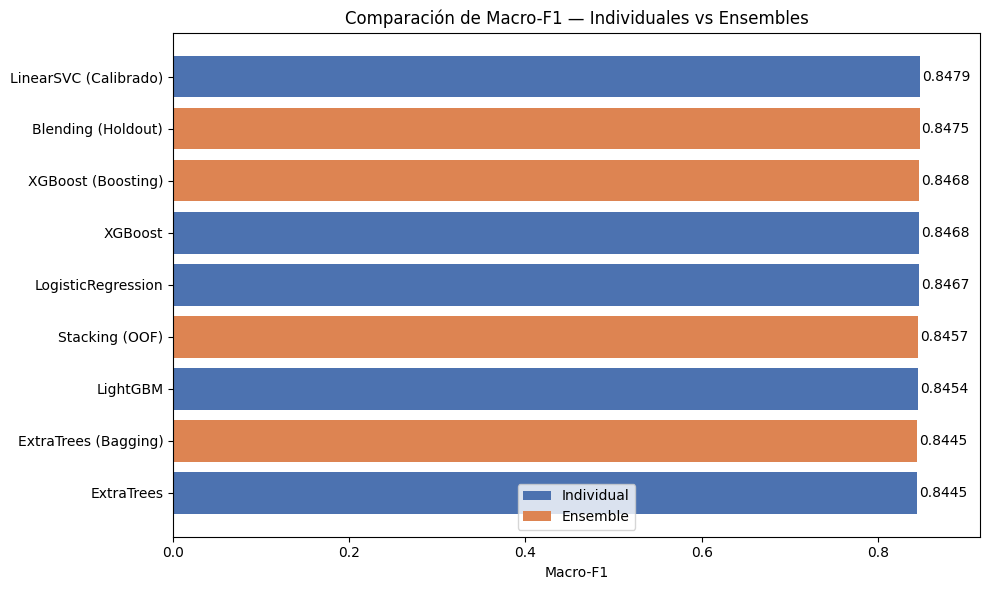

In [37]:
plot_df = comparison_df.sort_values("macro_f1", ascending=True)
color_map = {"Individual": "#4C72B0", "Ensemble": "#DD8452"}
bar_colors = [color_map[t] for t in plot_df["model_type"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df["model_name"], plot_df["macro_f1"], color=bar_colors)

for bar, val in zip(bars, plot_df["macro_f1"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=10)

legend_handles = [Patch(facecolor="#4C72B0", label="Individual"),
                  Patch(facecolor="#DD8452", label="Ensemble")]
ax.legend(handles=legend_handles, loc="lower center", fontsize=10)

ax.set_xlabel("Macro-F1")
ax.set_title("Comparación de Macro-F1 — Individuales vs Ensembles")
ax.set_xlim(0, max(plot_df["macro_f1"]) * 1.08)
plt.tight_layout()
plt.show()

#### Gráfica 2 - Matriz de confusión del mejor modelo global

La matriz de confusión del modelo con mayor Macro-F1 (ya sea individual o ensemble) permite inspeccionar en detalle dónde se producen los errores de clasificación. Los valores en la diagonal principal representan las predicciones correctas, mientras que los valores fuera de la diagonal indican confusiones entre clases. Es especialmente relevante observar si la clase minoritaria (clase 2: DR severa/proliferativa) presenta una tasa de error elevada, ya que es la clase más crítica desde el punto de vista clínico.

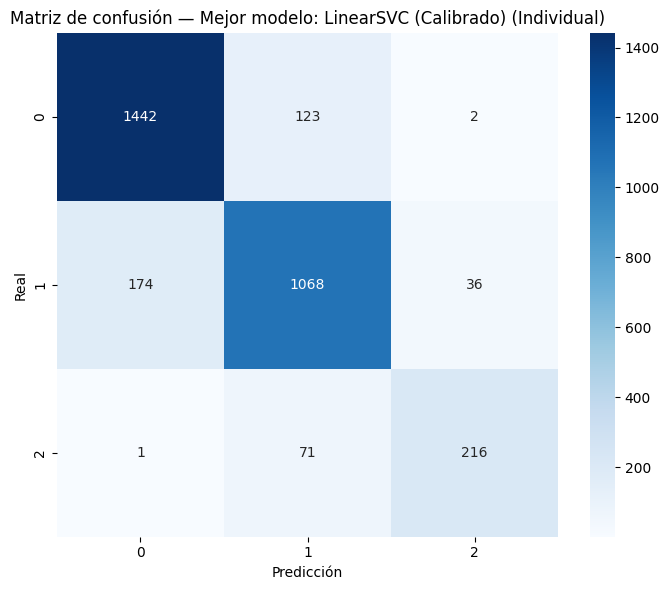

In [38]:
best_row = comparison_df.iloc[0]
best_name = best_row["model_name"]

ensemble_pred_map = {
    "XGBoost (Boosting)": xgb_val_pred,
    "ExtraTrees (Bagging)": et_val_pred,
    "Stacking (OOF)": stack_val_pred,
    "Blending (Holdout)": blend_val_pred,
}

if best_name in ensemble_pred_map:
    best_y_pred = ensemble_pred_map[best_name]
else:
    best_y_pred = np.argmax(
        individual_models_fitted[best_name].predict_proba(X_val), axis=1
    )

labels_sorted = sorted(int(x) for x in np.unique(y_val))
cm_best = confusion_matrix(y_val, best_y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
ax.set_title(f"Matriz de confusión — Mejor modelo: {best_name} ({best_row['model_type']})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

#### Gráfica 3 - F1-Score por clase y modelo (top-3 individuales + ensembles)

Esta gráfica de barras agrupadas muestra el F1-Score de cada clase para los top-3 modelos individuales y los 4 ensembles. Es crucial para detectar si algún modelo tiene un sesgo fuerte hacia una clase particular o si sacrifica rendimiento en la clase minoritaria. Un buen modelo debería mantener valores de F1 equilibrados a lo largo de las tres clases.

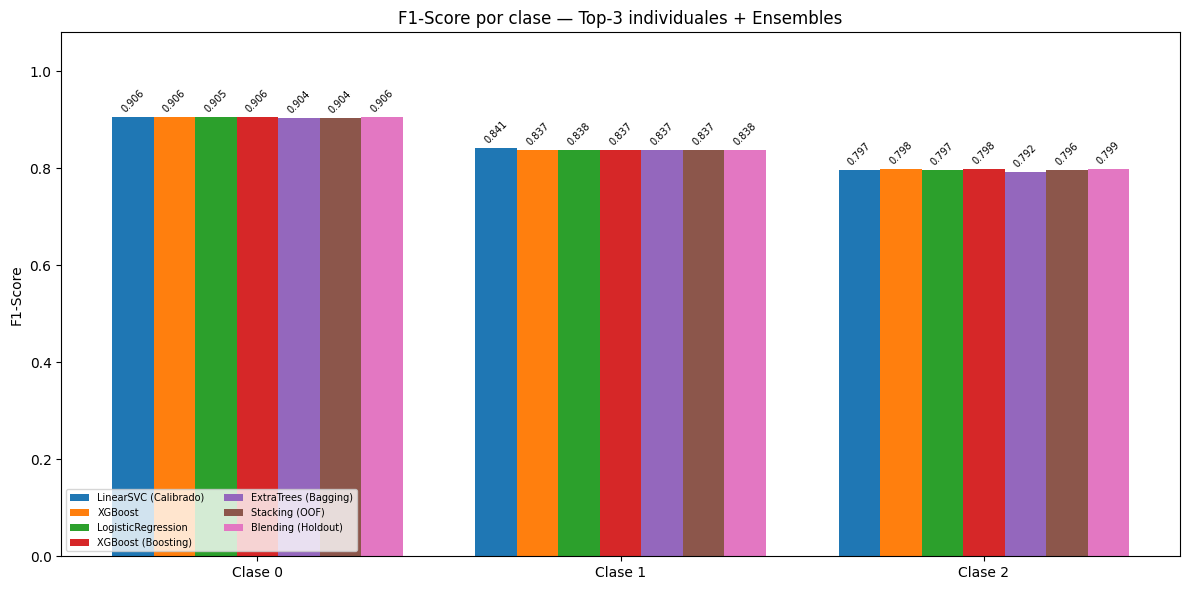

In [39]:
class_labels = [f"Clase {c}" for c in sorted(int(x) for x in np.unique(y_val))]
ensemble_names = ["XGBoost (Boosting)", "ExtraTrees (Bagging)", "Stacking (OOF)", "Blending (Holdout)"]
plot_model_names = best_base_names + ensemble_names
plot_model_names = [n for n in plot_model_names if n in per_class_f1_records]

x_pos = np.arange(len(class_labels))
bar_width = max(0.08, 0.8 / len(plot_model_names))
offsets = np.linspace(-(len(plot_model_names) - 1) * bar_width / 2,
                       (len(plot_model_names) - 1) * bar_width / 2,
                       len(plot_model_names))

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(plot_model_names):
    f1_vals = per_class_f1_records[name]
    bars = ax.bar(x_pos + offsets[i], f1_vals, bar_width, label=name)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x_pos)
ax.set_xticklabels(class_labels)
ax.set_ylabel("F1-Score")
ax.set_title("F1-Score por clase — Top-3 individuales + Ensembles")
ax.legend(loc="lower left", fontsize=7, ncol=2)
ax.set_ylim(0, 1.08)
plt.tight_layout()
plt.show()

#### Gráfica 4 - Trade-off: Tiempo de entrenamiento vs Macro-F1

Este gráfico de dispersión visualiza la relación entre el costo computacional (tiempo de entrenamiento) y el rendimiento (Macro-F1) de todos los modelos (individuales y ensembles). El modelo ideal se ubicaría en la esquina superior izquierda (alto F1, bajo tiempo). Los marcadores se diferencian por tipo (círculos para individuales, triángulos para ensembles). Esta gráfica es útil para la selección del modelo final cuando se consideran restricciones de recursos computacionales.

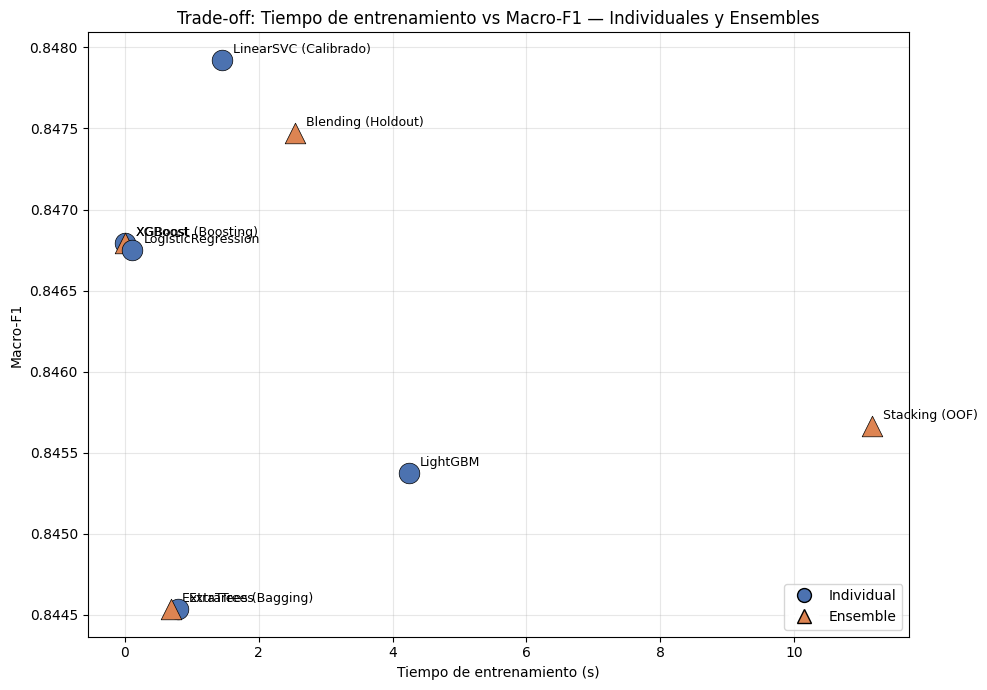

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))

marker_map = {"Individual": "o", "Ensemble": "^"}
color_type_map = {"Individual": "#4C72B0", "Ensemble": "#DD8452"}

for _, row in comparison_df.iterrows():
    m_type = row["model_type"]
    ax.scatter(row["train_time_s"], row["macro_f1"],
               s=220, marker=marker_map[m_type], color=color_type_map[m_type],
               zorder=5, edgecolors="black", linewidth=0.5)
    ax.annotate(row["model_name"],
                (row["train_time_s"], row["macro_f1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0",
           markersize=10, markeredgecolor="black", label="Individual"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#DD8452",
           markersize=10, markeredgecolor="black", label="Ensemble"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)

ax.set_xlabel("Tiempo de entrenamiento (s)")
ax.set_ylabel("Macro-F1")
ax.set_title("Trade-off: Tiempo de entrenamiento vs Macro-F1 — Individuales y Ensembles")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.7 Selección final del modelo

#### Resumen de los modelos evaluados

Tras completar el fine-tuning para ConvNeXt-Tiny y fijar el extractor como fuente única de representación, reevaluamos cinco clasificadores individuales sobre los embeddings fine-tuneados: `XGBoost`, `LightGBM`, `LinearSVC` calibrado, `ExtraTrees` y `Logistic Regression`. Con base en Macro-F1 en validación, seleccionamos los tres mejores como base learners para los ensambles heterogéneos, buscando combinar modelos con sesgos inductivos distintos y reducir debilidades particulares (varianza en árboles, linealidad en SVM y combinaciones en un meta-modelo).

A partir de estos componentes, construimos cuatro ensambles que cubren enfoques homogéneos y heterogéneos:

1) XGBoost (Boosting) - ensamble homogéneo tipo boosting, entrenado sobre los embeddings fine-tuneados y reutilizando hiperparámetros optimizados.
2) ExtraTrees (Bagging) - ensamble homogéneo tipo bagging con alto número de estimadores (p. ej., n_estimators=500) y manejo explícito del desbalance mediante pesos de clase.
2) Stacking (OOF) - ensamble heterogéneo que combina los top-3 individuales con un meta-learner (Logistic Regression), entrenado con predicciones out-of-fold para minimizar data leakage.
2) Blending (Holdout) - ensamble heterogéneo con los mismos base learners, donde el meta-modelo se ajusta sobre meta-features generadas en un holdout interno estratificado.

#### Criterios de selección.

El modelo final se eligió por su Macro-F1 en el conjunto de validación. Cuando las diferencias fueron marginales, aplicamos criterios secundarios:

- Estabilidad: desempeño equilibrado entre clases (F1 por clase y patrones de confusión).
- Eficiencia: tiempos de entrenamiento e inferencia.
- Simplicidad: preferencia por soluciones menos complejas cuando el rendimiento es comparable.

#### Consideraciones metodológicas.

Todos los modelos se entrenaron exclusivamente sobre los embeddings del `ConvNeXt-Tiny` fine-tuneado, sin reentrenar la CNN durante la etapa de ensambles. Para controlar el riesgo de data leakage en métodos heterogéneos, el stacking se construyó con predicciones OOF usando `StratifiedKFold(5)`, y el blending empleó un holdout estratificado separado para entrenar el meta-modelo. Además, `LinearSVC` se envolvió con `CalibratedClassifierCV` para habilitar predict_proba y asegurar que las salidas usadas como meta-features fueran comparables entre modelos.

## Conclusiones

En esta entrega nos enfocamos en técnicas de ensamble como evolución natural del pipeline desarrollado en Avance 4 y anteriores. La estrategia central consistió en:

1) Conservar el fine-tuning del backbone ConvNeXt-Tiny para adaptar el espacio de embeddings al dominio de retinopatía diabética.
2) Re-evaluar clasificadores individuales sobre este nuevo espacio de representación, ya que el ajuste del backbone modifica las características disponibles.
3) Construir y comparar cuatro ensambles (dos homogéneos y dos heterogéneos) para aprovechar fortalezas complementarias y reducir debilidades de modelos individuales.

Mientras que la entrega anterior se centró en comparar múltiples combinaciones de backbone + clasificador como candidatos individuales, en esta ocasión se trabaja sobre un embedding space finetuneado y se concentra en métodos de ensamble como mecanismo principal de mejora. La reevaluación de modelos individuales fue necesaria porque el fine-tuning altera la representación y, por lo tanto, los resultados previos no se pueden asumir como válidos sin validación bajo el nuevo extractor. A partir de esa reevaluación, seleccionamos los top-3 modelos como base learners para los enfoques heterogéneos, construyendo un Stacking (OOF) y un Blending (holdout) con control explícito de data leakage.

La decisión de mantener el esquema de 3 clases y aplicar aumento de datos selectivo para mitigar el desbalance permitió que los modelos aprendieran señales discriminativas para cada nivel de severidad. Esto se refleja en las métricas por clase y en las matrices de confusión, donde se observa un desempeño más estable y menos sesgado hacia la clase mayoritaria, particularmente en la clase más difícil (DR severa/proliferativa), que tiende a presentar mayor ambigüedad visual y menor frecuencia relativa.

En cuanto a los ensambles, se observó que tanto los enfoques homogéneos como los heterogéneos alcanzan rendimientos competitivos. Los ensambles heterogéneos (Stacking y Blending) combinan modelos de distinta naturaleza (métodos basados en árboles, SVM lineal y un meta-modelo lineal) para explotar fortalezas complementarias. Los modelos de árboles capturan interacciones no lineales en el espacio de embeddings, mientras que el meta-learner aprende una combinación estable de predicciones. El `Stacking OOF` utiliza predicciones out-of-fold con `StratifiedKFold` para construir meta-features sin contaminación del entrenamiento, y el Blending emplea un holdout estratificado, que separa explícitamente el ajuste del meta-modelo de la evaluación final.

El modelo final se seleccionó por su Macro-F1 en validación, considerando además la estabilidad entre clases, la eficiencia computacional y la simplicidad cuando las diferencias fueron marginales. La tabla comparativa unificada, que integra modelos individuales y ensambles, permite una evaluación transparente y trazable de todos los candidatos bajo el mismo espacio de representación fine-tuneado.

Como trabajo futuro, consideramos relevante explorar enfoques end-to-end con entrenamiento completo bajo un presupuesto computacional mayor, investigar variantes de ensamble como weighted averaging o stacking multinivel con regularización y aplicar calibración post-hoc de probabilidades para mejorar la confiabilidad de las predicciones, especialmente en escenarios clínicos donde la incertidumbre es tan importante como el acierto.

Referencias:

- *Baliarsingh, Santos Kumar, and Prabhu Prasad Dev. "An Early diagnosis of diabetic retinopathy using ConvNeXt." 2023 10th International Conference on Signal Processing and Integrated Networks (SPIN). IEEE, 2023.*
- *Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). Densely connected convolutional networks. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4700-4708).*
- *Kumar, V., Sharma, G., & Garg, D. (2023, November). Analysis of Early Detection and Prediction of Diabetic Retinopathy by Optimize Deep Learning with XG-Boosting. In Conference on Smart Generation Computing and Communication Networks (pp. 61-69). Cham: Springer Nature Switzerland.*
- *Nahiduzzaman, M., Islam, M. R., Goni, M. O. F., Anower, M. S., Ahsan, M., Haider, J., & Kowalski, M. (2023). Diabetic retinopathy identification using parallel convolutional neural network based feature extractor and ELM classifier. Expert Systems with Applications, 217, 119557.*
- *Nneji, G. U., Cai, J., Deng, J., Monday, H. N., Hossin, M. A., & Nahar, S. (2022). Identification of diabetic retinopathy using weighted fusion deep learning based on dual-channel fundus scans. Diagnostics, 12(2), 540.*
- *Meenakshi, K., Kishore, D., & Srinivasa Rao, C. (2024, October). Enhanced Detection of Diabetic Retinopathy Through Transfer Learning with DenseNet-121 and XGBoost Classifier. In International Conference on Computer & Communication Technologies (pp. 409-419). Singapore: Springer Nature Singapore.*
- *Song P, Wu Y. DR-ConvNeXt: DR classification method for reconstructing ConvNeXt model structure. J Xray Sci Technol. 2025 Mar;33(2):448-460. doi: 10.1177/08953996241311190. Epub 2025 Feb 12. PMID: 39973787.*
- *VanderPlas, J. (2022). Python Data Science Handbook (2nd ed.). O´Reilly Media.*
- *Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). CRISP-ML(Q). The ML Lifecycle Process. MLOps. INNOQ.*